# CNC Predictive Maintenance


## Import Dataset


Load required libraries and data loader utils to extract the CNC dataset from the local .h5 files. This dataset contains vibration sensor data from CNC machines, which will be used for predicitve maintenance analysis.


In [1]:
import os
import numpy as np
import pandas as pd
from pathlib import Path
from utils import data_loader_utils
import itertools

The dataset is organized hierachically, with each machine having its own folder. Each machine folder contains operation folders (e.g. `op1`, `op2`, etc.). Within each operation folder, there are `good` and `bad` folders. The `good` folders contain .h5 files with vibration data from normal machine operations, while the `bad` folders contain .h5 files with vibration data from machines that are experiencing faults or failures.


In [2]:
machines = ["M01", "M02", "M03"]
process_names = [
    "OP00",
    "OP01",
    "OP02",
    "OP03",
    "OP04",
    "OP05",
    "OP06",
    "OP07",
    "OP08",
    "OP09",
    "OP10",
    "OP11",
    "OP12",
    "OP13",
    "OP14",
]
labels = ["good", "bad"]
path_to_dataset = Path("../data/").absolute()

The data_generator function can efficiently load the .h5 data for analysis. It reads each .h5 file and extracts the data to an efficient dataframe for further analysis.


In [3]:
def data_generator():
    for process_name, machine, label in itertools.product(
        process_names, machines, labels
    ):
        data_path = os.path.join(path_to_dataset, machine, process_name, label)
        data_list, data_label = data_loader_utils.load_tool_research_data(
            data_path, label=label, verbose=False
        )

        for data_array, label_ in zip(data_list, data_label):
            # Break apart the label_
            # Example label_: M01_Aug_2019_OP00_000_good
            # Get M01, *, OP00, 000, good
            label_parts = label_.split("_")
            machine_id = label_parts[0]
            tool_operation_date = label_parts[1] + "_" + label_parts[2]
            tool_operation_id = label_parts[3]
            tool_operation_instance = int(label_parts[4])
            tool_operation_status = label_parts[5]

            yield [
                machine_id,
                tool_operation_id,
                tool_operation_instance,
                tool_operation_date,
                tool_operation_status,
                label_,
                data_array.astype(np.int16),
            ]


df = pd.DataFrame(
    data_generator(),
    columns=[
        "machine_id",
        "tool_operation_id",
        "tool_operation_instance",
        "tool_operation_date",
        "tool_operation_status",
        "label",
        "vibration_data",
    ],
)

display(df.head())
print(f"There are {len(df)} labeled samples of vibration data in the dataset.")

,machine_id,tool_operation_id,tool_operation_instance,tool_operation_date,tool_operation_status,label,vibration_data
0,M01,OP00,0,Aug_2019,good,M01_Aug_2019_OP00_000_good,"[[-9, 9, -1011], [-21, 19, -1011], [-15, 23, -..."
1,M01,OP00,1,Aug_2019,good,M01_Aug_2019_OP00_001_good,"[[-15, 21, -1009], [-13, 23, -1013], [-13, 19,..."
2,M01,OP00,3,Aug_2019,good,M01_Aug_2019_OP00_003_good,"[[-9, 15, -1018], [-27, 15, -1005], [-13, 21, ..."
3,M01,OP00,4,Aug_2019,good,M01_Aug_2019_OP00_004_good,"[[-33, 15, -1005], [-37, 7, -1011], [-35, 21, ..."
4,M01,OP00,5,Aug_2019,good,M01_Aug_2019_OP00_005_good,"[[-5, 17, -1016], [-17, 23, -1018], [-7, 42, -..."


There are 1702 labeled samples of vibration data in the dataset.


Each sample contains the following data:

- `machine_id`: Identifier for the CNC machine (M01, M02, or M03)
- `tool_operation_id`: Identifier for the tool operation (OP00 through OP14)
- `tool_operation_instance`: Instance number of the tool operation for the given machine and date
- `tool_operation_date`: Date the tool operation was performed (e.g., Aug_2019)
- `tool_operation_status`: Status of the tool operation (good or bad)
- `label`: Combined label of the above fields for easy identification
- `vibration_data`: Numpy array of vibration data collected during the tool operation
  - These are x,y,z axis vibration data sampled at 2 kHz from a tri-axial CISS sensor


## Example Data Samples


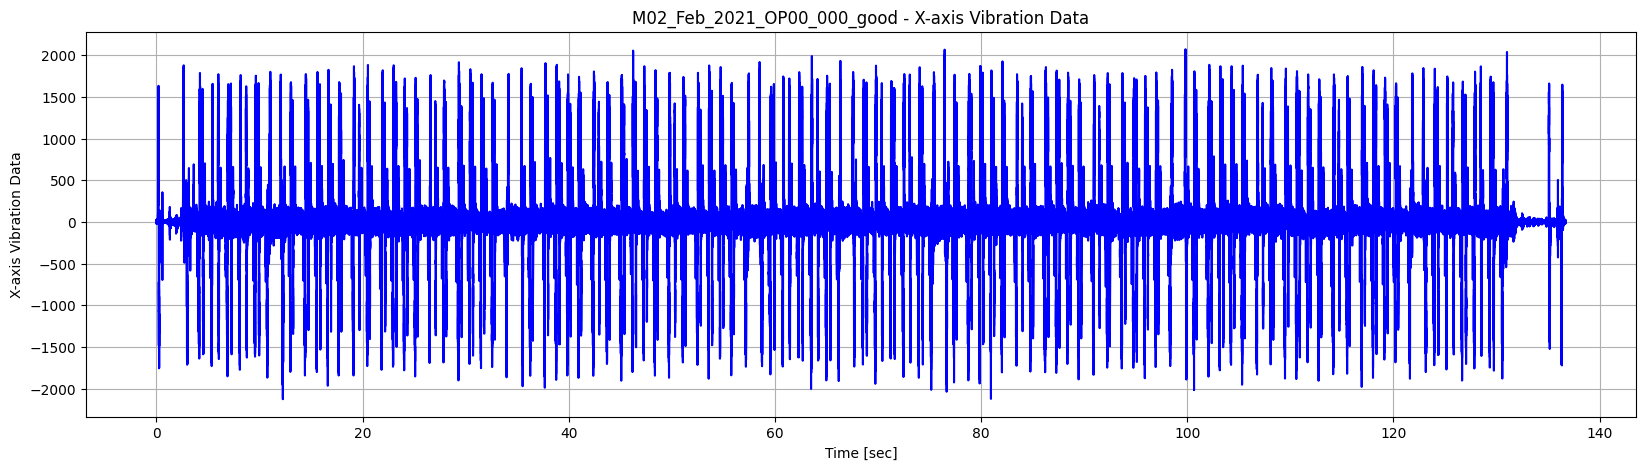

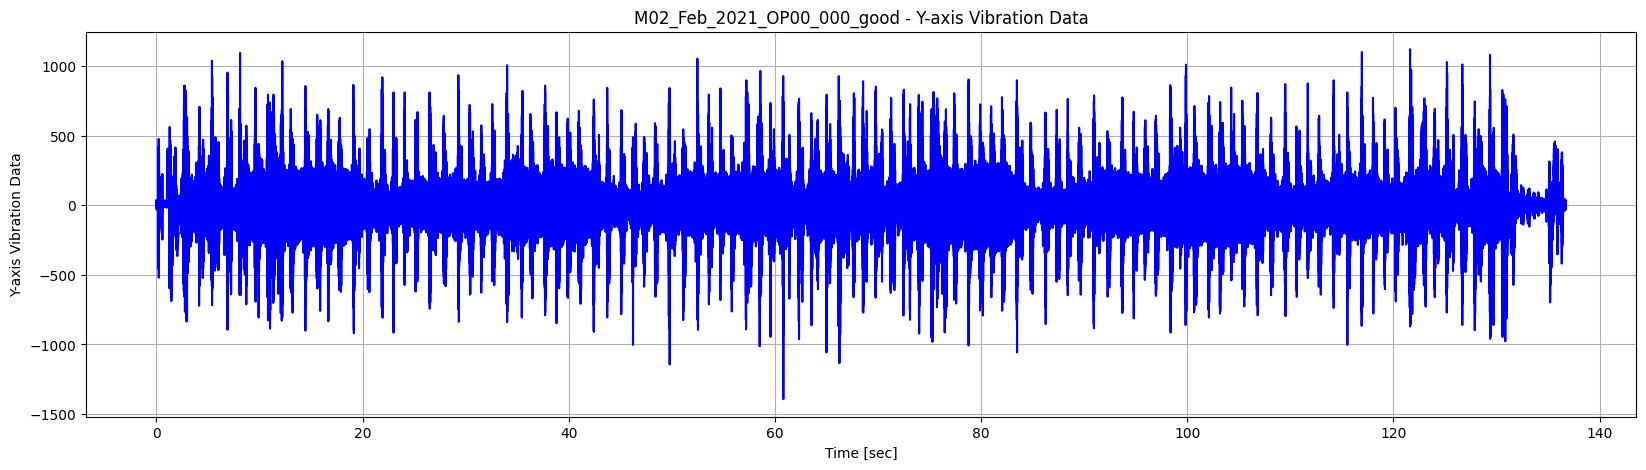

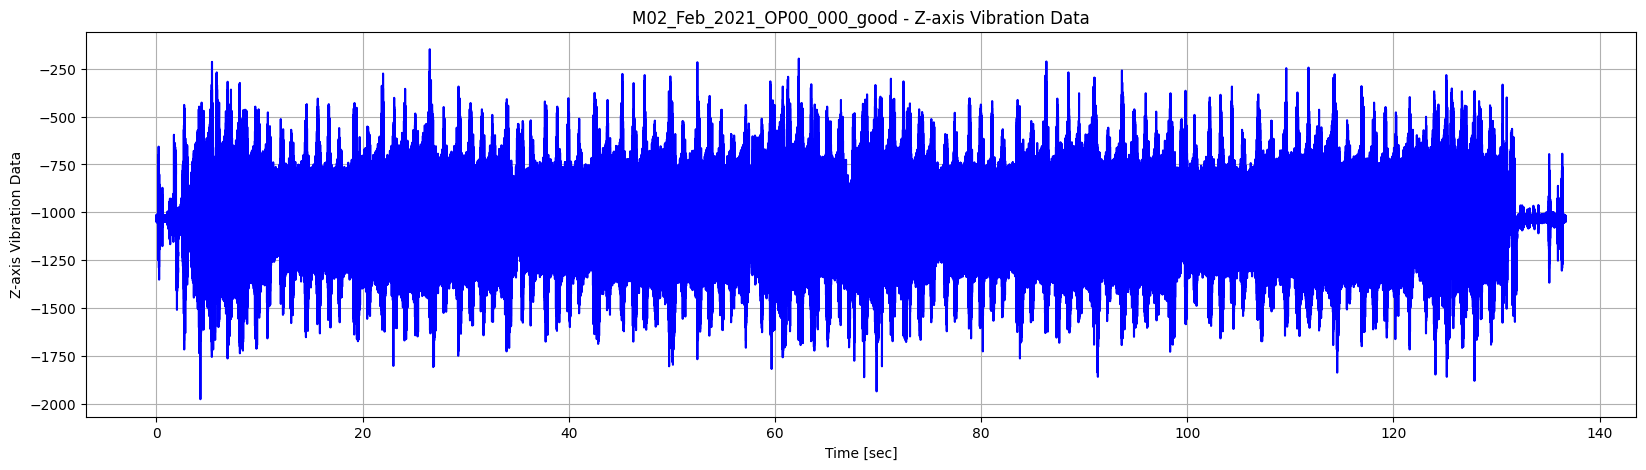

In [4]:
# plot good sample for reference
good_row = df[
    (df["machine_id"] == "M02")
    & (df["tool_operation_status"] == "good")
    & (df["tool_operation_id"] == "OP00")
    & (df["tool_operation_instance"] == 0)
    & (df["tool_operation_date"] == "Feb_2021")
].iloc[0]

data_loader_utils.plot_vibration_data(
    good_row["vibration_data"], label=good_row["label"]
)

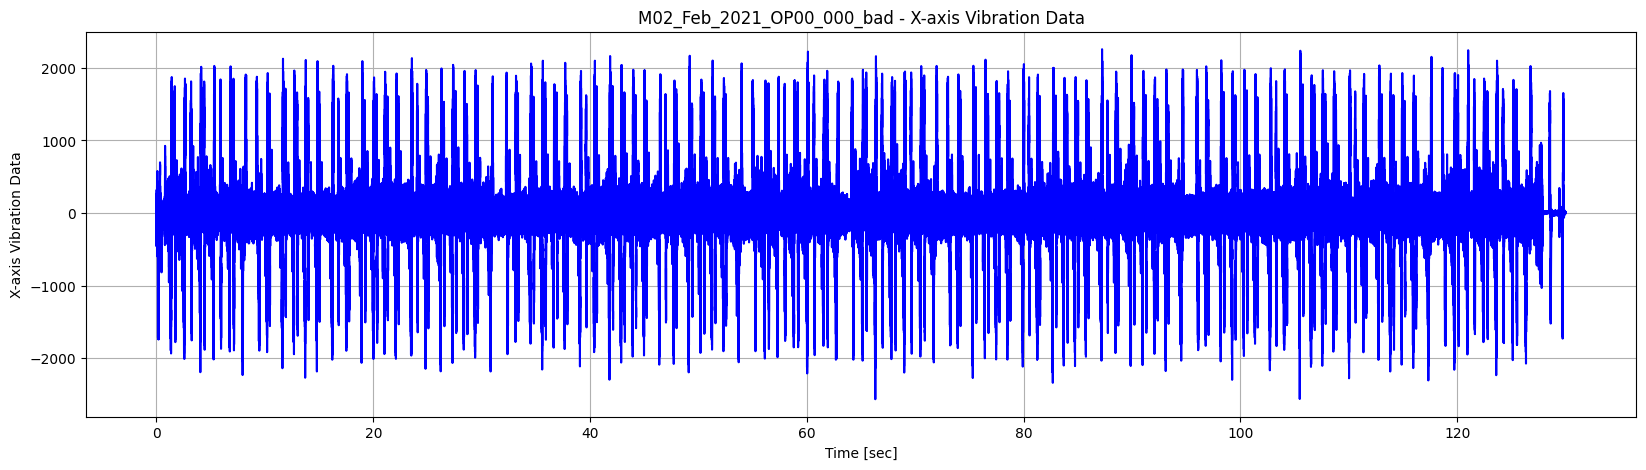

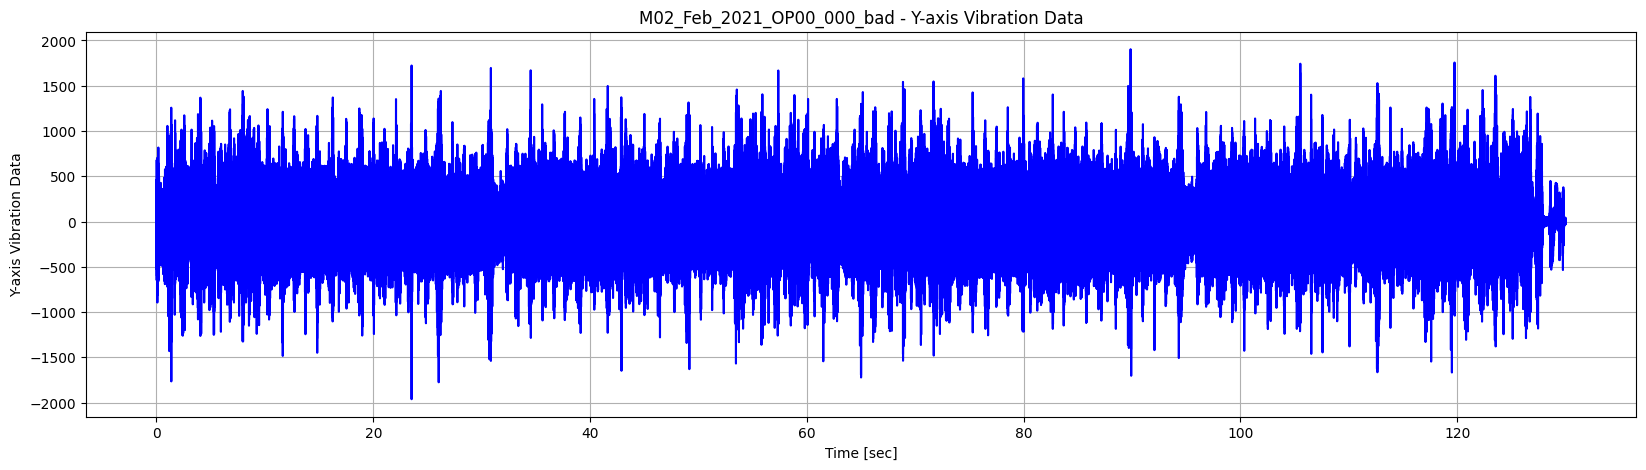

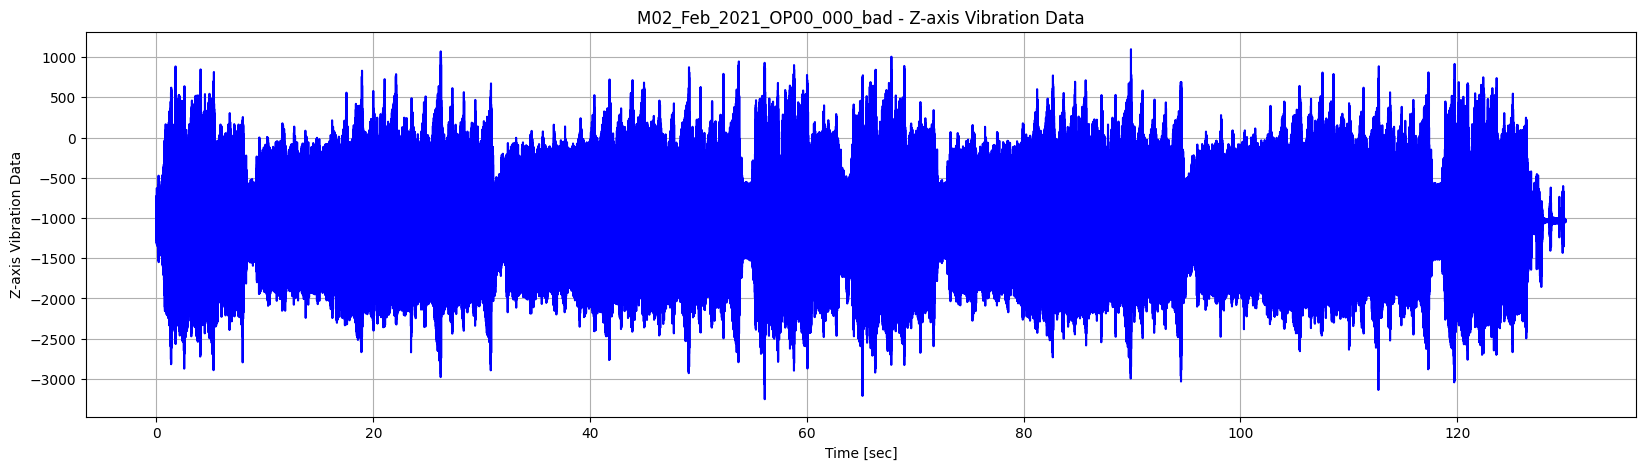

In [5]:
# plot bad sample for reference
bad_row = df[
    (df["machine_id"] == "M02")
    & (df["tool_operation_status"] == "bad")
    & (df["tool_operation_id"] == "OP00")
    & (df["tool_operation_instance"] == 0)
    & (df["tool_operation_date"] == "Feb_2021")
].iloc[0]

data_loader_utils.plot_vibration_data(bad_row["vibration_data"], label=bad_row["label"])

## Investigating temporal patterns and data quality

This section inspects temporal distribution of samples (by `tool_operation_date` and status) and checks data quality: missing values, inconsistent lengths, basic summary statistics, and outlier/anomaly detection using RMS + z-score (threshold = 3).


In [6]:
# Imports for analysis and plotting
import matplotlib.pyplot as plt
import seaborn as sns


# Compute basic per-sample statistics from the vibration arrays
def _extract_stats(arr):
    a = np.asarray(arr)
    # handle common tri-axial shape (N,3) or flat arrays
    if a.ndim == 2 and a.shape[1] == 3:
        length = a.shape[0]
        nan_count = int(np.isnan(a).sum())
        rms = float(np.sqrt(np.mean(a.astype(np.float64) ** 2)))
        max_abs = float(np.max(np.abs(a)))
        mean_x, mean_y, mean_z = [float(x) for x in a.mean(axis=0)]
    else:
        flat = a.ravel()
        length = flat.size
        nan_count = int(np.isnan(flat).sum())
        rms = float(np.sqrt(np.mean(flat.astype(np.float64) ** 2)))
        max_abs = float(np.max(np.abs(flat)))
        mean_x = mean_y = mean_z = np.nan
    return {
        "length": int(length),
        "nan_count": int(nan_count),
        "rms": rms,
        "max_abs": max_abs,
        "mean_x": mean_x,
        "mean_y": mean_y,
        "mean_z": mean_z,
    }


# apply and expand into dataframe columns
stats_df = df["vibration_data"].apply(lambda x: pd.Series(_extract_stats(x)))
df = pd.concat([df, stats_df], axis=1)

# Quick summary
print("Dataset shape:", df.shape)
print("Missing value counts (per column):")
print(df.isnull().sum())
print("Total NaNs inside vibration arrays:", df["nan_count"].sum())
print("Vibration length stats:")
print(df["length"].describe())
print("RMS stats:")
print(df["rms"].describe())

Dataset shape: (1702, 14)
Missing value counts (per column):
machine_id                 0
tool_operation_id          0
tool_operation_instance    0
tool_operation_date        0
tool_operation_status      0
label                      0
vibration_data             0
length                     0
nan_count                  0
rms                        0
max_abs                    0
mean_x                     0
mean_y                     0
mean_z                     0
dtype: int64
Total NaNs inside vibration arrays: 0.0
Vibration length stats:
count      1702.000000
mean     104936.098707
std       60507.876966
min       26793.000000
25%       62747.000000
50%       87040.000000
75%      130048.000000
max      317440.000000
Name: length, dtype: float64
RMS stats:
count    1702.000000
mean      656.132980
std        22.068073
min       619.257776
25%       643.006082
50%       652.621494
75%       664.743206
max       840.067122
Name: rms, dtype: float64


tool_operation_status,bad,good
tool_operation_date,,
Aug_2019,14,724
Aug_2020,0,99
Aug_2021,9,111
Feb_2019,39,85
Feb_2020,0,272
Feb_2021,8,341


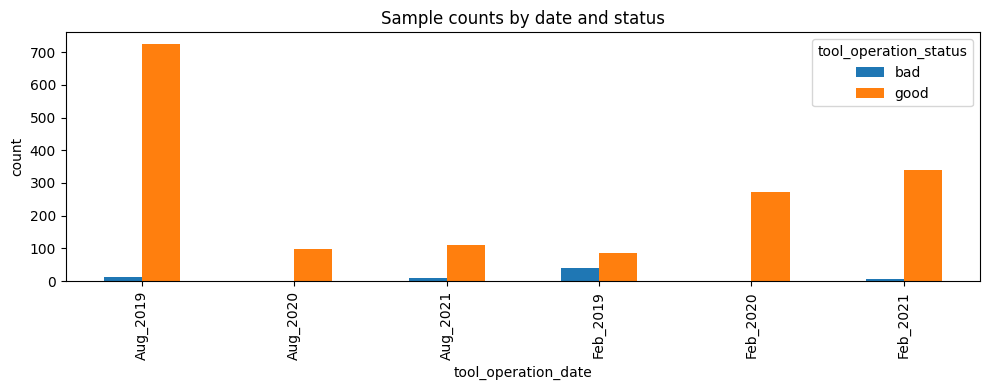

In [7]:
# Temporal distribution: counts per date and status
counts = (
    df.groupby(["tool_operation_date", "tool_operation_status"])
    .size()
    .unstack(fill_value=0)
)
display(counts)

counts.plot(kind="bar", stacked=False, figsize=(10, 4))
plt.title("Sample counts by date and status")
plt.ylabel("count")
plt.tight_layout()
plt.show()

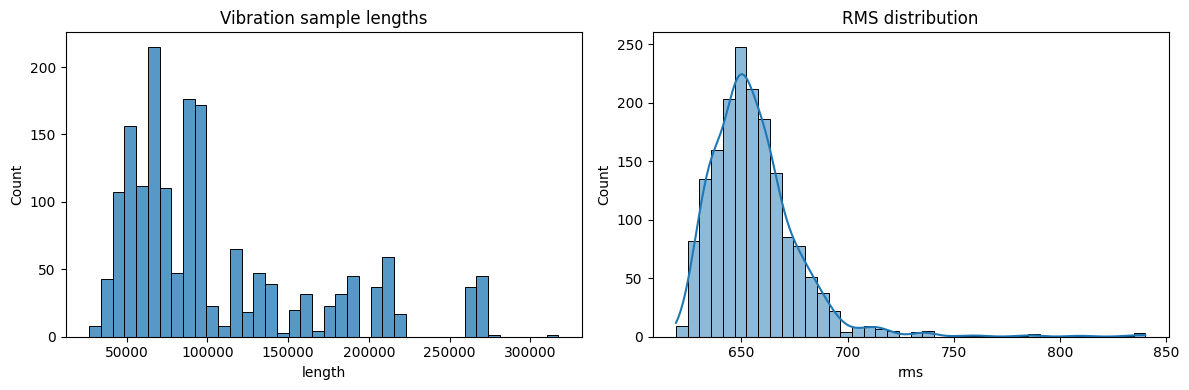

In [8]:
# Distribution plots for length and RMS
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(df["length"], bins=40, kde=False)
plt.title("Vibration sample lengths")
plt.subplot(1, 2, 2)
sns.histplot(df["rms"], bins=40, kde=True)
plt.title("RMS distribution")
plt.tight_layout()
plt.show()

In [9]:
# Outlier detection on 'rms' using z-score (robust to small sets?)
rms_mean = df["rms"].mean()
rms_std = df["rms"].std(ddof=0)
df["rms_z"] = (df["rms"] - rms_mean) / (rms_std + 1e-12)
df["is_outlier_rms"] = df["rms_z"].abs() > 3.0
print("Outlier counts (RMS z>|3|):", df["is_outlier_rms"].sum())

# Show some outlier examples
if df["is_outlier_rms"].any():
    display(
        df[df["is_outlier_rms"]].head()[
            [
                "label",
                "tool_operation_date",
                "tool_operation_status",
                "length",
                "rms",
                "rms_z",
            ]
        ]
    )
else:
    print("No RMS outliers found by z>3 rule.")

Outlier counts (RMS z>|3|): 21


,label,tool_operation_date,tool_operation_status,length,rms,rms_z
55,M02_Feb_2021_OP00_000_bad,Feb_2021,bad,260000.0,787.820497,5.969086
378,M03_Feb_2021_OP02_000_bad,Feb_2021,bad,72000.0,762.891110,4.839095
515,M02_Feb_2019_OP04_000_bad,Feb_2019,bad,124731.0,738.039290,3.712621
516,M02_Feb_2019_OP04_002_bad,Feb_2019,bad,125751.0,738.481995,3.732687
701,M01_Aug_2021_OP06_000_bad,Aug_2021,bad,176000.0,738.835677,3.748719


Short samples (below 1st percentile): 18
Long samples (above 99th percentile): 12
Sample index: 55


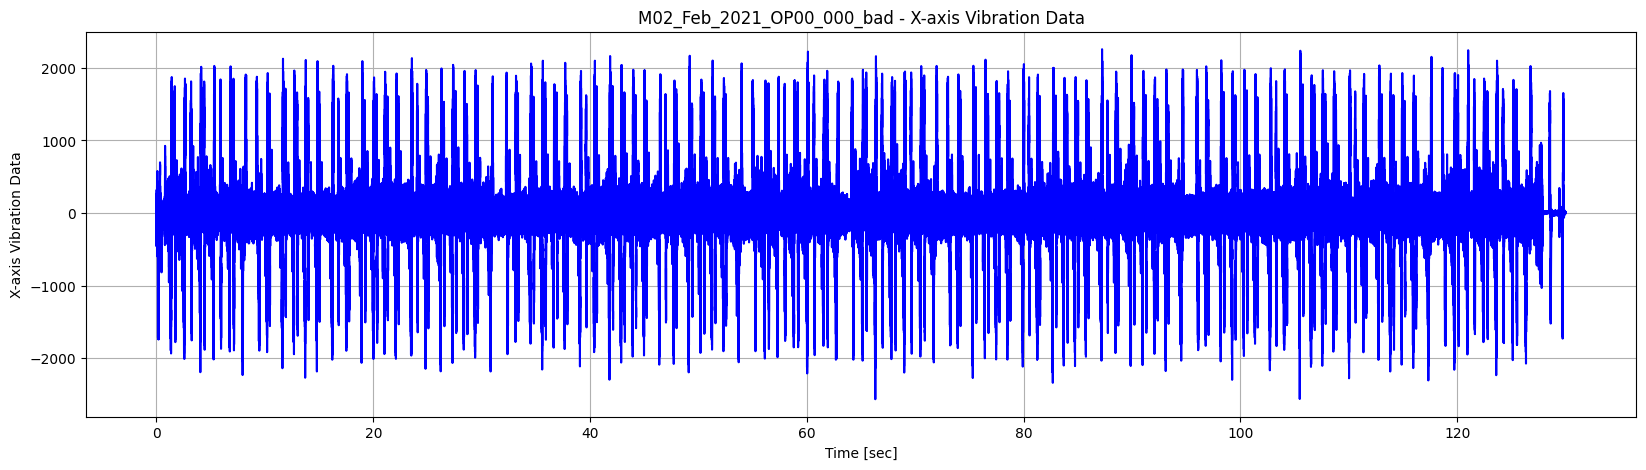

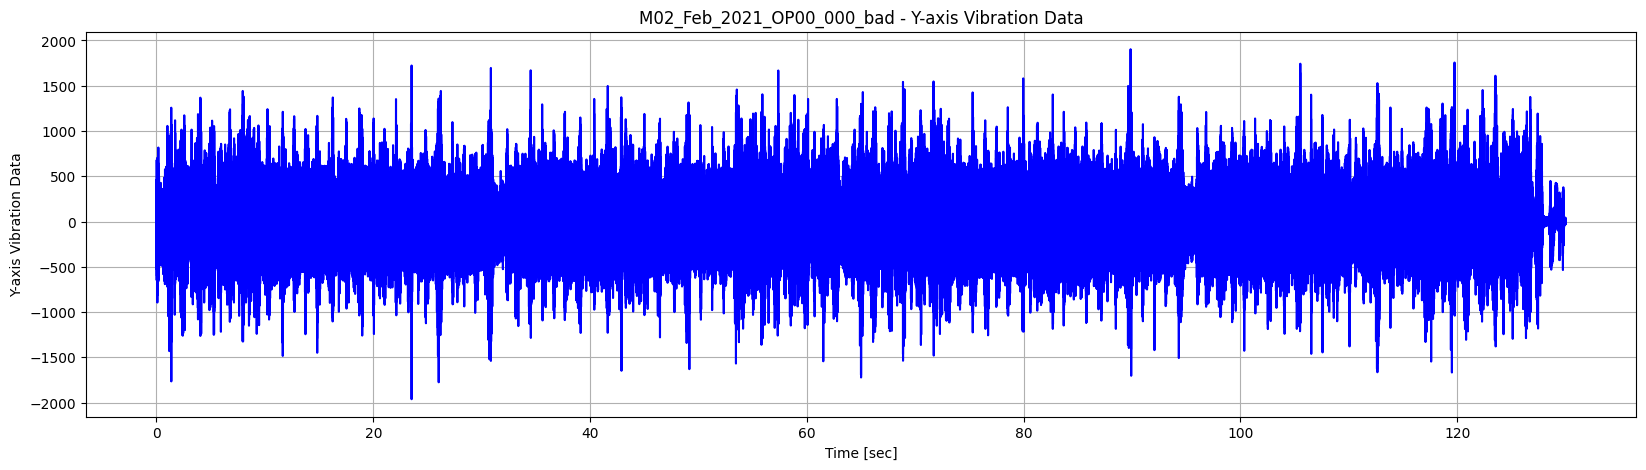

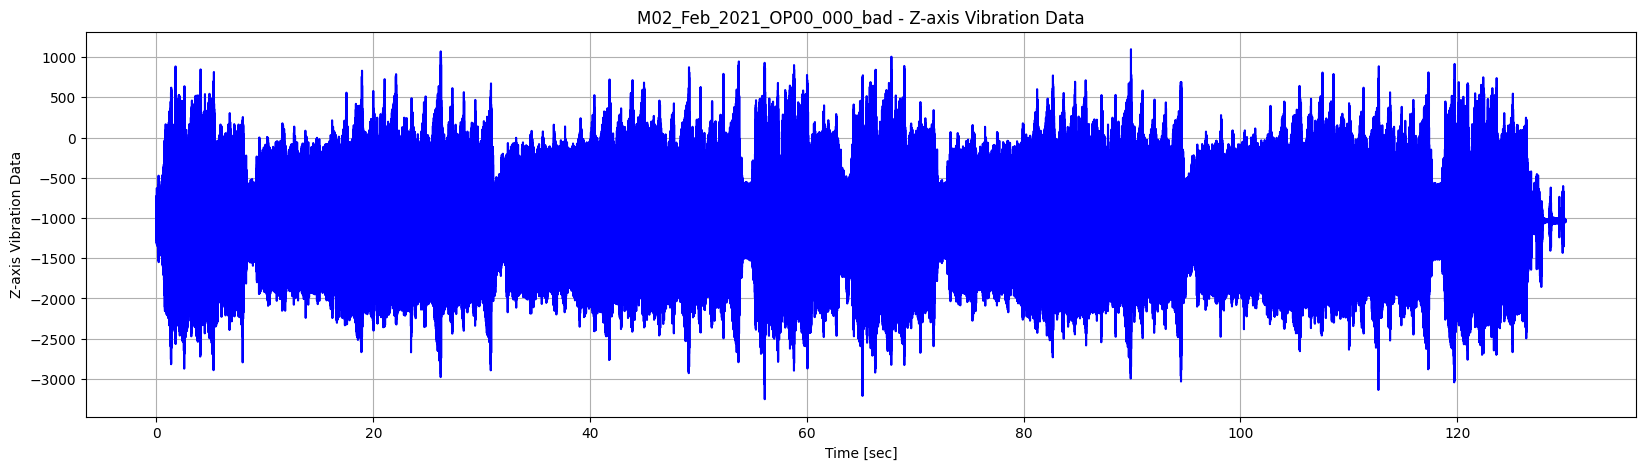

Sample index: 378


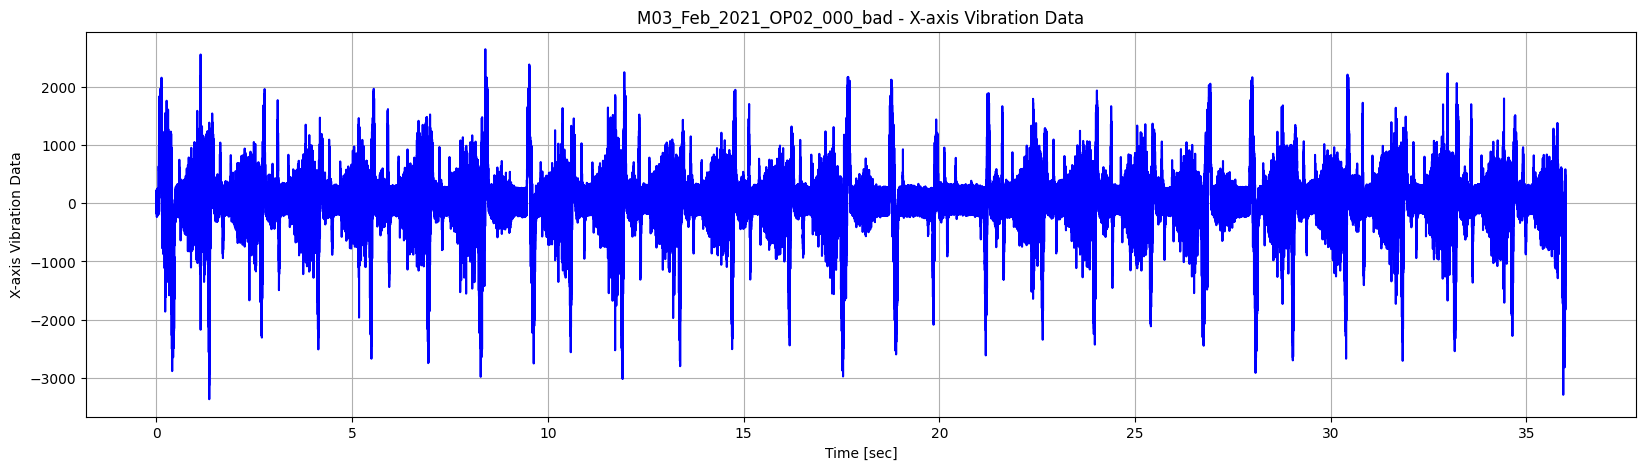

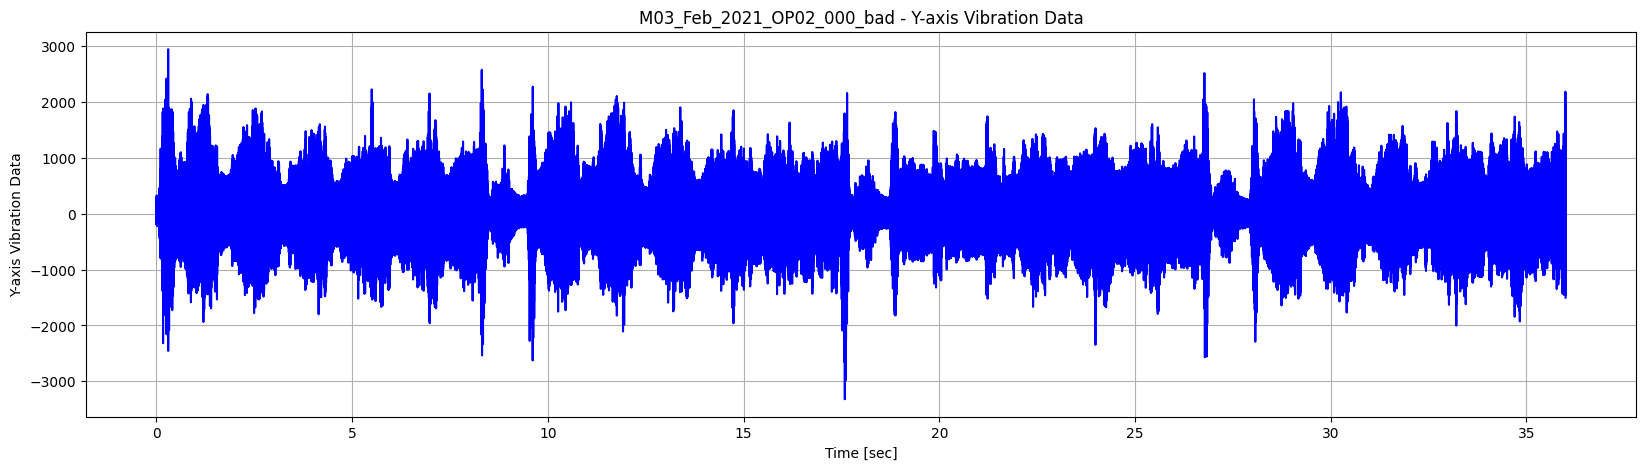

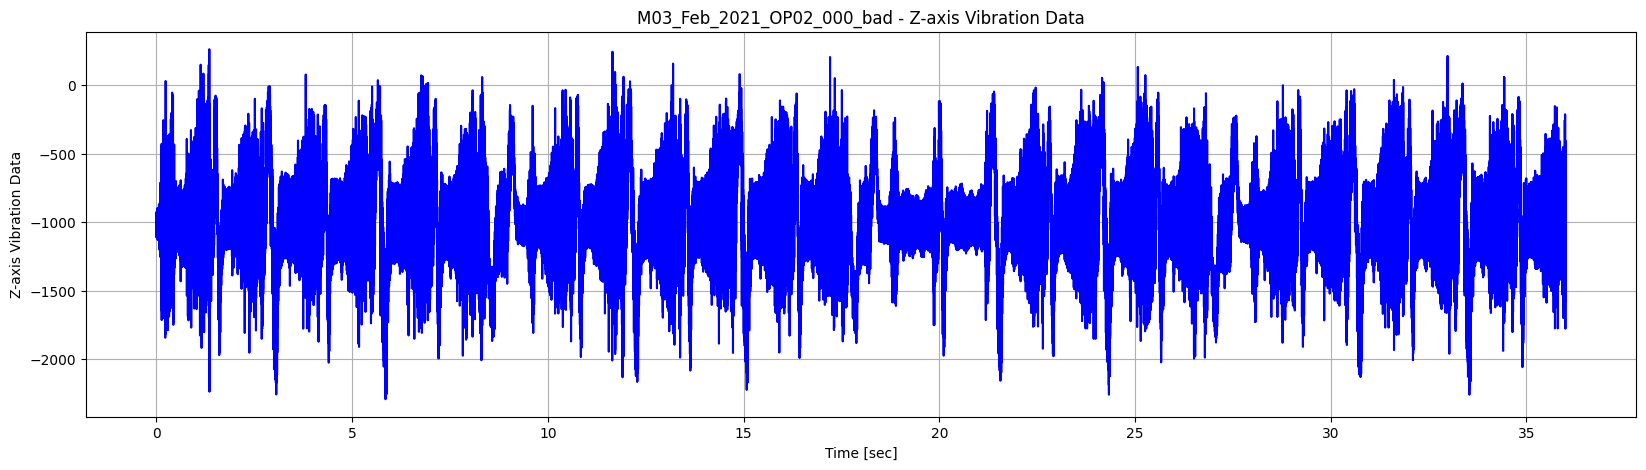

Sample index: 225


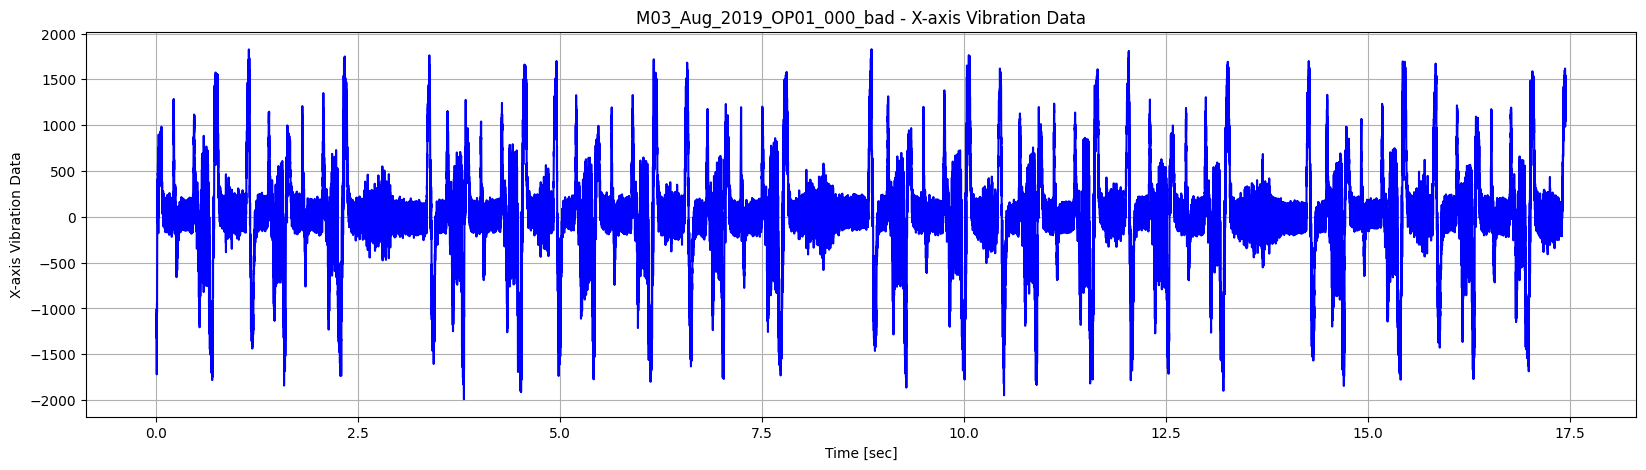

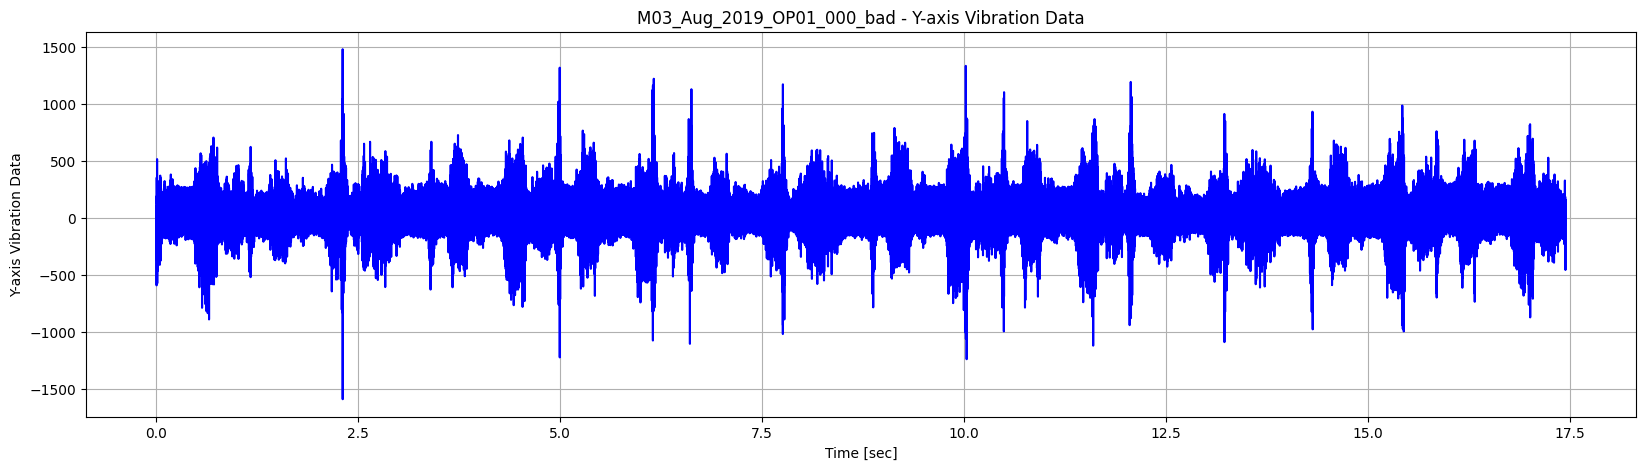

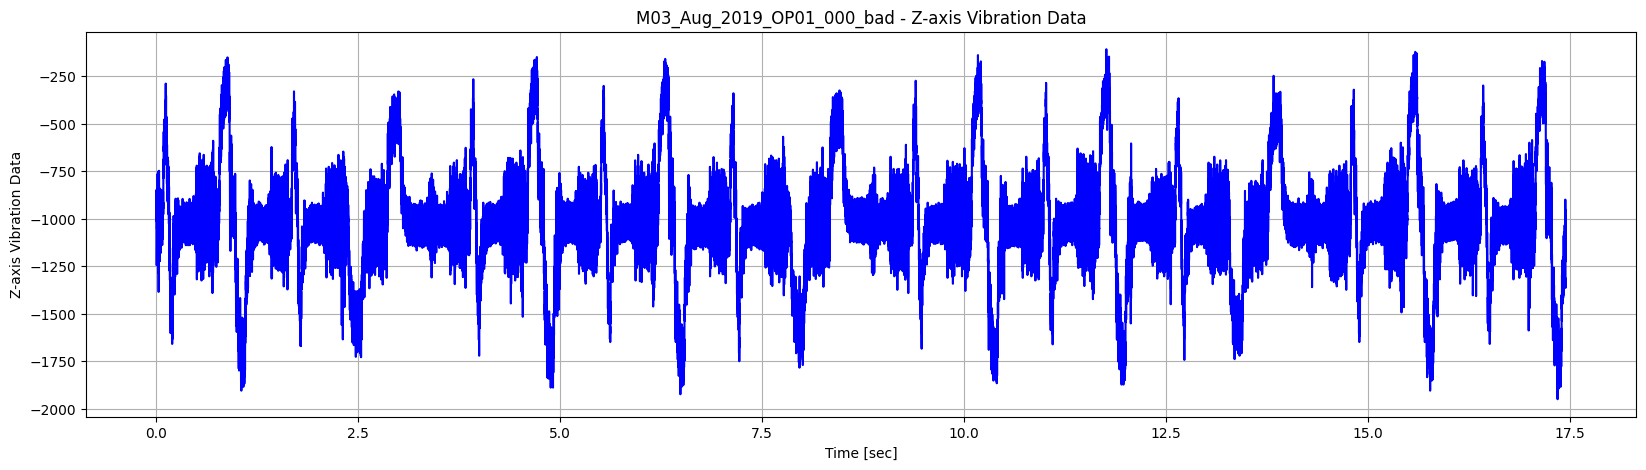

Sample index: 595


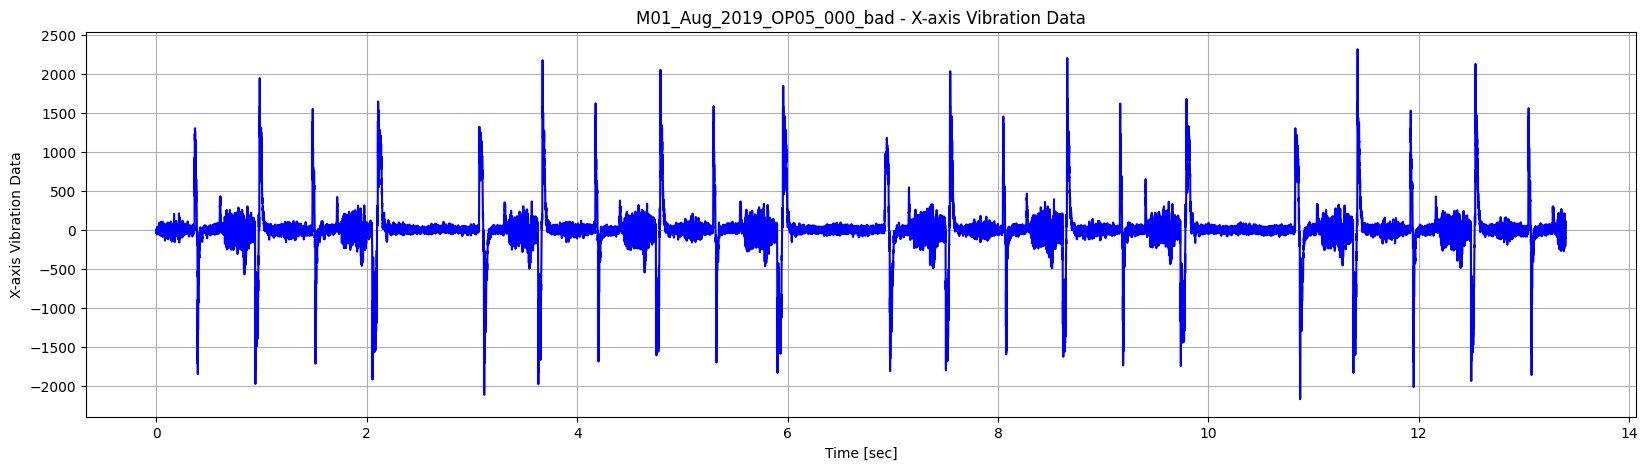

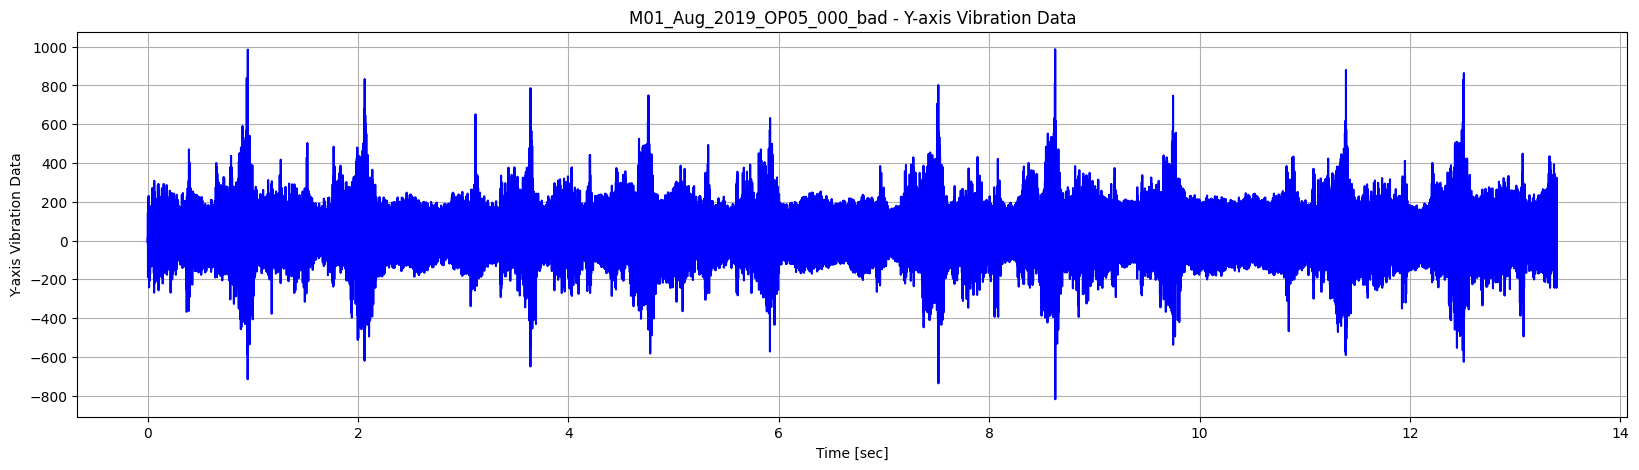

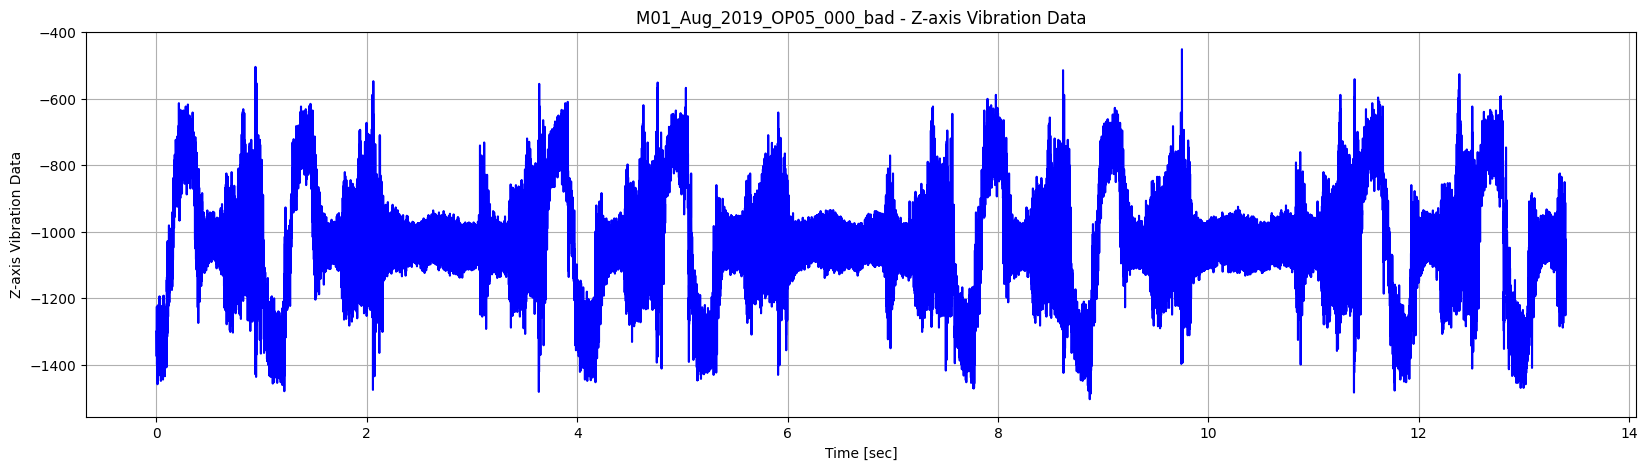

In [10]:
# Investigate samples with suspicious lengths (very short or very long)
short = df[df["length"] < df["length"].quantile(0.01)]
long = df[df["length"] > df["length"].quantile(0.99)]
print("Short samples (below 1st percentile):", len(short))
print("Long samples (above 99th percentile):", len(long))

# Visual check for a couple of outlier samples (if present)
examples = (
    df[df["is_outlier_rms"]].head(2).index.tolist() + short.head(2).index.tolist()
)
for idx in examples:
    print("Sample index:", idx)
    row = df.loc[idx]
    data_loader_utils.plot_vibration_data(row["vibration_data"], label=row["label"])

## Exploratory Data Analysis (EDA)

This EDA covers: class imbalance, feature distributions (length, RMS, max abs, means), time-series patterns aggregated by date/status, and correlation analysis among numeric features.


### Class imbalance: overall and by machine/process/date


Overall class counts:
tool_operation_status
good    1632
bad       70
Name: count, dtype: int64


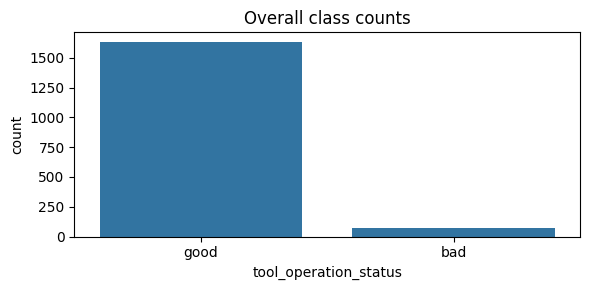

tool_operation_status,bad,good
machine_id,,
M01,34,485
M02,27,617
M03,9,530


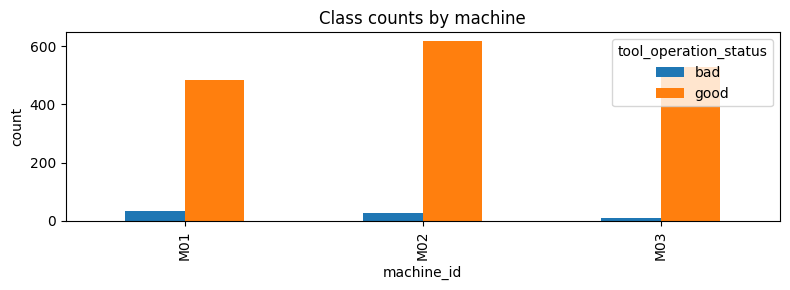

tool_operation_status,bad,good
tool_operation_id,,
OP01,7,136
OP02,4,148
OP05,6,114
OP07,10,148
OP08,7,112
OP10,7,112
OP12,5,118
OP13,0,142


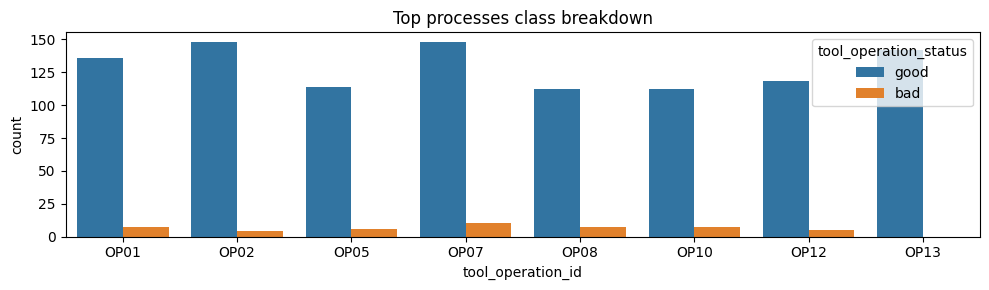

In [11]:
# Overall class imbalance
print("Overall class counts:")
print(df["tool_operation_status"].value_counts())

plt.figure(figsize=(6, 3))
sns.countplot(x="tool_operation_status", data=df)
plt.title("Overall class counts")
plt.tight_layout()
plt.show()

# By machine
by_machine = (
    df.groupby(["machine_id", "tool_operation_status"]).size().unstack(fill_value=0)
)
display(by_machine)
by_machine.plot(kind="bar", stacked=False, figsize=(8, 3))
plt.title("Class counts by machine")
plt.ylabel("count")
plt.tight_layout()
plt.show()

# By process id (show top 8 processes by total samples)
proc_counts = df["tool_operation_id"].value_counts()
top_procs = proc_counts.head(8).index.tolist()
display(
    df[df["tool_operation_id"].isin(top_procs)]
    .groupby(["tool_operation_id", "tool_operation_status"])
    .size()
    .unstack(fill_value=0)
)
plt.figure(figsize=(10, 3))
sns.countplot(
    data=df[df["tool_operation_id"].isin(top_procs)],
    x="tool_operation_id",
    hue="tool_operation_status",
)
plt.title("Top processes class breakdown")
plt.tight_layout()
plt.show()

### Feature distributions: length, rms, max_abs, and means


**length**: In the histograms below, we see that most machining cycles are consistently captured and that the data collection process is stable. Though a few outliers exist that could represent incomplete captures from very short signals or delayed recordings from very long signals.

**rms**: The RMS per job shows that each job has it's own unique distribution. For example, a heaver cutting job might have naturally higher RMS while a light finishing job may have lower RMS.

**max_abs**: Indicates whether each job may have a high impact point relative to it's job. Typically this distribution should have a slight right skew caused by a small amount of high ABS values.

**means**: The mean values for each axis helps give us context into each process and may point out if there is any mounting drift or calibration issues.

,length,rms,max_abs,mean_x,mean_y,mean_z
count,1702.000000,1702.000000,1702.000000,1702.000000,1702.000000,1702.000000
mean,104936.098707,656.132980,2734.856052,3.342817,17.375085,-1024.768130
std,60507.876966,22.068073,1183.608778,6.169227,12.854840,8.802328
min,26793.000000,619.257776,1774.000000,-8.565300,-3.146913,-1050.753033
25%,62747.000000,643.006082,2131.000000,-1.335673,4.274453,-1032.048423
50%,87040.000000,652.621494,2330.000000,1.787200,17.785556,-1021.494456
75%,130048.000000,664.743206,2684.000000,9.663662,30.413069,-1016.142065
max,317440.000000,840.067122,9234.000000,24.799726,90.018052,-1006.618941


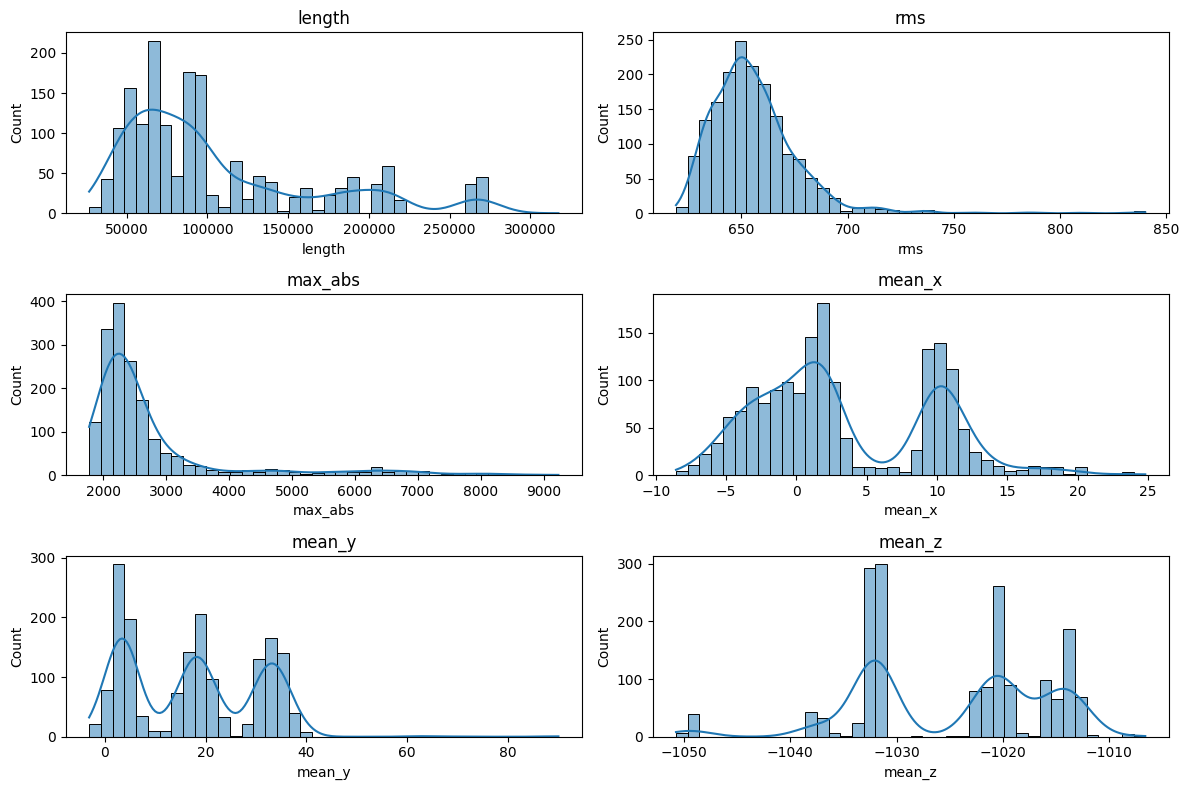

In [12]:
num_cols = ["length", "rms", "max_abs", "mean_x", "mean_y", "mean_z"]
display(df[num_cols].describe())

plt.figure(figsize=(12, 8))
for i, col in enumerate(num_cols):
    plt.subplot(3, 2, i + 1)
    sns.histplot(df[col].dropna(), bins=40, kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()

### Violin plots of RMS by status


Here the violin plots show the overall behavior of each job and how they differ between a good job and a bad one. Here we can see that a job with a wider violin and lower central tendencies tend to be categorized as good while bad jobs tend to have thinner and have a higher central tendancy. This lines up with our expectation that a bad job with high central tendencies tend to have higher RMS values which could indicate increased cutting resistance, tool wear, or reduced structural stability. On the contrary, if a bad profile has a very low and wide central tendency, then this may indicate that the machine has chatter, unstable cutting, or load fluctuations.

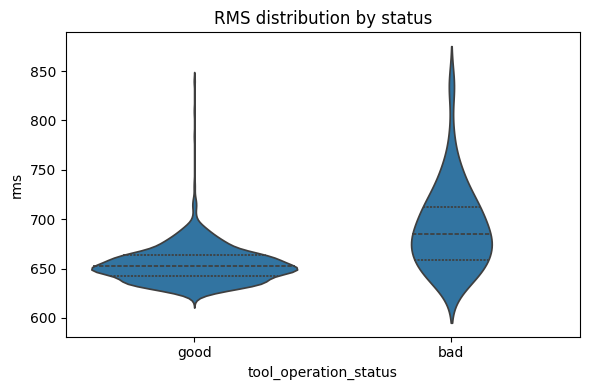

In [13]:
plt.figure(figsize=(6, 4))
sns.violinplot(x="tool_operation_status", y="rms", data=df, inner="quartile")
plt.title("RMS distribution by status")
plt.tight_layout()
plt.show()

### Time-series pattern: mean RMS per date and status


tool_operation_status,bad,good
tool_operation_date,,
Aug_2019,677.564000,652.509151
Aug_2020,NaN,669.116711
Aug_2021,701.212066,654.138422
Feb_2019,691.461866,654.402592
Feb_2020,NaN,658.444279
Feb_2021,705.511796,652.025840


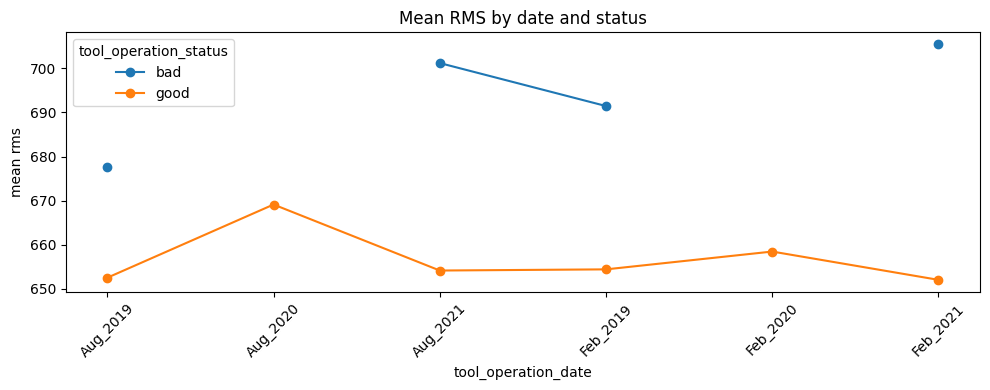

In [14]:
ts = (
    df.groupby(["tool_operation_date", "tool_operation_status"])["rms"].mean().unstack()
)
display(ts)

ts.plot.line(marker="o", figsize=(10, 4))
plt.title("Mean RMS by date and status")
plt.ylabel("mean rms")
plt.xlabel("tool_operation_date")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Correlation analysis among numeric features


The correlation matrix of the defined features show several modest correlations. The observed correlation between Max Absolute vibration and Mean X suggests that large vibration spikes (impacts or instability events) tend to occur when the machine is already experiencing sustained directional loading along the X-axis. In mechanical terms, this implies that shocks are not random but are more likely to happen when the tool or structure is under lateral stress, such as during uneven tool engagement, structural flex, or early-stage wear. This relationship indicates that impulsive vibration events are influenced by underlying load conditions, meaning high peaks may be more diagnostically significant when accompanied by a directional bias. Overall, this correlation reflects meaningful machine behavior, where directional force contributes to instability and increases the likelihood of impact-like vibration events.

The strong correlation between Mean Y and Mean Z indicates that vibration bias in these two axes tends to shift together, suggesting a shared directional influence rather than independent motion. Mechanically, this likely reflects the combined force vector generated during machining, where cutting loads are applied at an angle rather than along a single axis, causing simultaneous displacement in both the Y and Z directions. This behavior may also be influenced by machine geometry, structural compliance, or slight sensor orientation, all of which can couple motion between axes. Overall, this correlation represents consistent directional loading during operations and provides insight into how forces are transmitted through the machine structure rather than indicating a fault on its own.

Top correlations (absolute)


corr_coeff
mean_y  mean_z     0.677439
max_abs mean_x     0.458031
rms     max_abs    0.278489
        mean_x     0.267179
mean_x  mean_z    -0.211996
max_abs mean_z     0.203624
mean_x  mean_y    -0.172088
rms     mean_z    -0.163258
length  mean_x    -0.077292
        max_abs    0.068136
rms     mean_y    -0.059379
length  mean_z     0.054546
max_abs mean_y     0.046638
length  mean_y     0.021751
        rms        0.003301

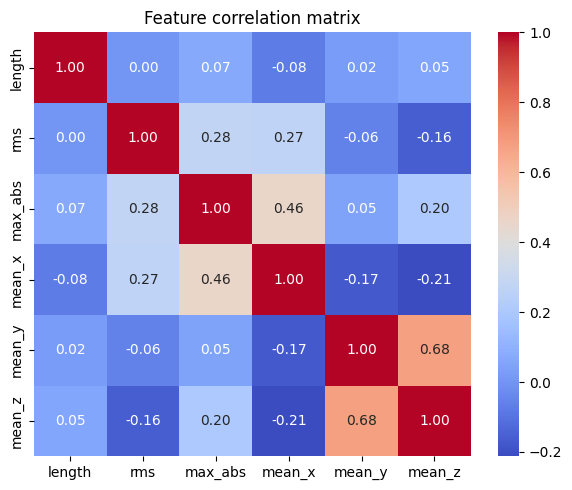

In [15]:
corr = df[num_cols].corr()
print("Top correlations (absolute)")
corr_df = pd.DataFrame(corr.unstack(), columns=["corr_coeff"])
corr_df["abs_corr"] = corr_df["corr_coeff"].abs()
duplicate_labels = [(col, col) for col in num_cols]
checked_lables = []
for label in corr_df.index:
    checked_lables.append(label)
    reversed_label = (label[1], label[0])
    if reversed_label in checked_lables:
        continue
    if reversed_label in corr_df.index:
        duplicate_labels.append(reversed_label)
display(
    corr_df.sort_values(by="abs_corr", ascending=False)
    .drop(labels=duplicate_labels)
    .drop(columns=["abs_corr"])
)
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature correlation matrix")
plt.tight_layout()
plt.show()

### Vibration intensity by operation

Different CNC operations have distinct vibration profiles. This heatmap shows mean per-axis standard deviation across all 15 operations, motivating operation-aware feature engineering and model design.

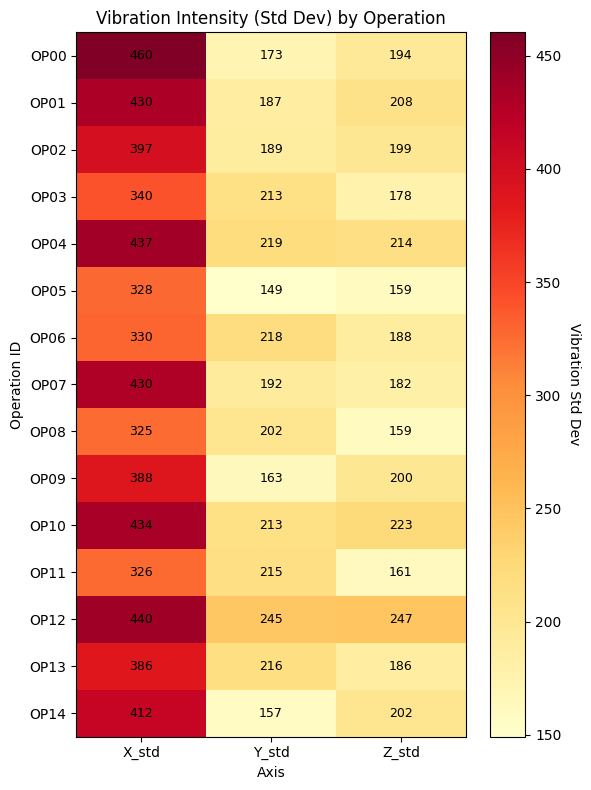

In [16]:
# Compute per-axis std for each sample (vibration_data is shape (N, 3))
def _axis_stds(arr):
    a = np.asarray(arr)
    if a.ndim == 2 and a.shape[1] == 3:
        return pd.Series({"X_std": float(a[:, 0].std()),
                          "Y_std": float(a[:, 1].std()),
                          "Z_std": float(a[:, 2].std())})
    flat = a.ravel().astype(np.float64)
    s = float(flat.std())
    return pd.Series({"X_std": s, "Y_std": s, "Z_std": s})

axis_std_df = df["vibration_data"].apply(_axis_stds)
df_op = pd.concat([df[["tool_operation_id"]], axis_std_df], axis=1)

# Mean vibration std grouped by operation
op_stats = df_op.groupby("tool_operation_id")[["X_std", "Y_std", "Z_std"]].mean()

fig, ax = plt.subplots(figsize=(6, 8))
im = ax.imshow(op_stats.values, cmap="YlOrRd", aspect="auto")
ax.set_xticks(range(3))
ax.set_xticklabels(["X_std", "Y_std", "Z_std"])
ax.set_yticks(range(len(op_stats)))
ax.set_yticklabels(op_stats.index)
cbar = ax.figure.colorbar(im, ax=ax)
cbar.ax.set_ylabel("Vibration Std Dev", rotation=-90, va="bottom")
for i in range(len(op_stats)):
    for j in range(3):
        ax.text(j, i, f"{op_stats.values[i, j]:.0f}",
                ha="center", va="center", color="black", fontsize=9)
ax.set_title("Vibration Intensity (Std Dev) by Operation")
ax.set_xlabel("Axis")
ax.set_ylabel("Operation ID")
plt.tight_layout()
plt.show()


# Model Research and Selection

| Task | Baseline | Deep Learning |
|------|----------|---------------|
| Tool Condition Classification (good/bad) | Random Forest | 1D-CNN |
| Vibration Time Series Forecasting | Linear Regression | LSTM |

**1D-CNN** — learns local vibration patterns from the raw signal; no hand-crafted features needed.

**LSTM** — captures temporal dependencies in vibration sequences that linear models miss.


# Baseline 1: Random Forest Classifier


In [ ]:

import warnings; warnings.filterwarnings('ignore')
from scipy import stats
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, precision_recall_curve,
    roc_auc_score, average_precision_score, f1_score,
    mean_squared_error, mean_absolute_error, r2_score
)
import os; os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
print('TF:', tf.__version__)


TF: 2.20.0


In [ ]:
# Feature extraction function for tri-axial vibration data
# had help from Claude to get the function right
def extract_features(arr):
    a = arr.astype(np.float64)
    feats = {}
    # Compute per-axis features
    for i, ax in enumerate(['X', 'Y', 'Z']):
        d = a[:, i]
        rms = np.sqrt(np.mean(d**2))
        feats.update({
            f'{ax}_mean':  np.mean(d),
            f'{ax}_std':   np.std(d),
            f'{ax}_rms':   rms,
            f'{ax}_range': np.ptp(d),
            f'{ax}_skew':  stats.skew(d),
            f'{ax}_kurt':  stats.kurtosis(d),
            f'{ax}_iqr':   np.percentile(d, 75) - np.percentile(d, 25),
            f'{ax}_crest': np.max(np.abs(d)) / rms if rms > 0 else 0,
            f'{ax}_zcr':   np.sum(np.diff(np.sign(d - np.mean(d))) != 0) / len(d),
        })
    mag = np.sqrt(np.sum(a**2, axis=1))
    feats['mag_mean'] = np.mean(mag)
    feats['mag_std']  = np.std(mag)
    return feats

# Extract features for all samples and prepare for classification
rows = []
for _, row in df.iterrows():
    f = extract_features(row['vibration_data'])
    f['label'] = row['tool_operation_status']
    rows.append(f)

# Create feature dataframe and prepare X, y for classification
feat_df   = pd.DataFrame(rows)
feat_cols = [c for c in feat_df.columns if c != 'label']
X_clf = feat_df[feat_cols].values
y_clf = (feat_df['label'] == 'bad').astype(int).values
print(f'Features: {X_clf.shape[1]}  |  Good: {(y_clf==0).sum()}  |  Bad: {(y_clf==1).sum()}')


Features: 29  |  Good: 1632  |  Bad: 70


In [ ]:
# Train/test split, scaling, and Random Forest classification
X_tr, X_te, y_tr, y_te = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf)
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_te_s = scaler.transform(X_te)

class_w = {0: 1, 1: int((y_tr==0).sum() / max((y_tr==1).sum(), 1))}
rf = RandomForestClassifier(
    n_estimators=200, max_depth=10, min_samples_leaf=2,
    class_weight=class_w, random_state=42, n_jobs=-1)
rf.fit(X_tr_s, y_tr)

# Evaluation on test set
y_pred  = rf.predict(X_te_s)
y_proba = rf.predict_proba(X_te_s)[:, 1]
cm_rf   = confusion_matrix(y_te, y_pred)

# Print evaluation metrics
print(classification_report(y_te, y_pred, target_names=['Good', 'Bad']))
print(f'ROC-AUC : {roc_auc_score(y_te, y_proba):.4f}')
print(f'PR-AUC  : {average_precision_score(y_te, y_proba):.4f}')

# Cross-validation for more robust performance estimates
skf    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_f1  = cross_val_score(rf, X_tr_s, y_tr, cv=skf, scoring='f1')
cv_auc = cross_val_score(rf, X_tr_s, y_tr, cv=skf, scoring='roc_auc')

# Print cross-validation results
print(f'\n5-Fold CV  F1: {cv_f1.mean():.4f} +/- {cv_f1.std()*2:.4f}')
print(f'5-Fold CV AUC: {cv_auc.mean():.4f} +/- {cv_auc.std()*2:.4f}')


              precision    recall  f1-score   support

        Good       0.99      1.00      1.00       327
         Bad       1.00      0.79      0.88        14

    accuracy                           0.99       341
   macro avg       1.00      0.89      0.94       341
weighted avg       0.99      0.99      0.99       341

ROC-AUC : 0.9993
PR-AUC  : 0.9874

5-Fold CV  F1: 0.7718 +/- 0.1517
5-Fold CV AUC: 0.9802 +/- 0.0601


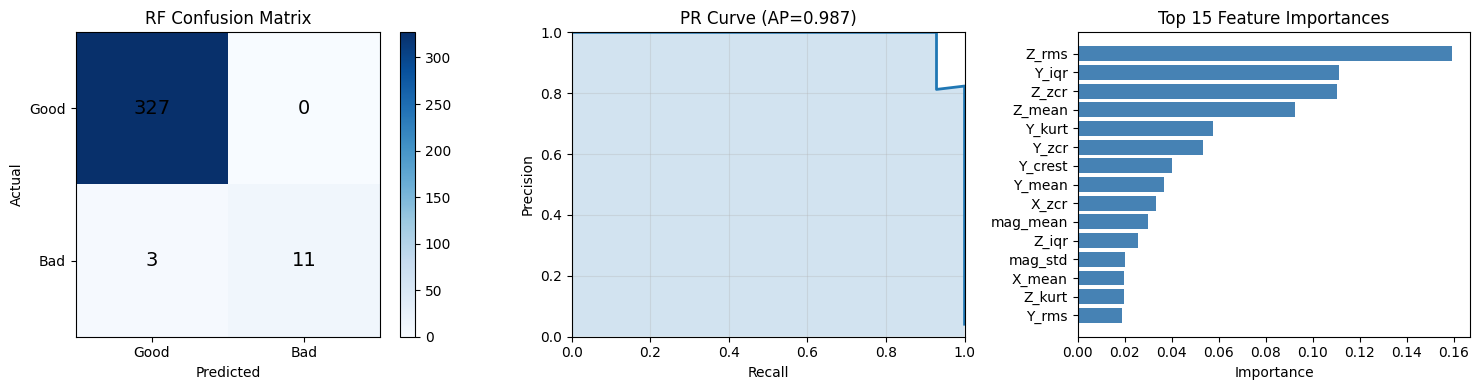

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Confusion matrix heatmap
im = axes[0].imshow(cm_rf, cmap='Blues')
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm_rf[i,j], ha='center', va='center', fontsize=14)
        axes[0].set_xticks([0,1])
        axes[0].set_yticks([0,1])
        axes[0].set_xticklabels(['Good','Bad'])
        axes[0].set_yticklabels(['Good','Bad'])
        axes[0].set_xlabel('Predicted')
        axes[0].set_ylabel('Actual')
        axes[0].set_title('RF Confusion Matrix')
        plt.colorbar(im, ax=axes[0])

# ROC Curve
prec, rec, _ = precision_recall_curve(y_te, y_proba)
axes[1].plot(rec, prec, linewidth=2)
axes[1].fill_between(rec, prec, alpha=0.2)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title(f'PR Curve (AP={average_precision_score(y_te, y_proba):.3f})')
axes[1].set_xlim([0,1])
axes[1].set_ylim([0,1])
axes[1].grid(alpha=0.3)

# Feature importance bar plot
imp = pd.Series(rf.feature_importances_, index=feat_cols).nlargest(15).sort_values()
axes[2].barh(imp.index, imp.values, color='steelblue')
axes[2].set_xlabel('Importance')
axes[2].set_title('Top 15 Feature Importances')

plt.tight_layout()
plt.show()


# Deep Learning 1: 1D-CNN Classifier

Raw tri-axial vibration (X, Y, Z) fed directly as a multivariate time series. The network learns discriminative patterns without hand-crafted features.

Architecture: `Conv1D → BN → MaxPool` × 2, then `GlobalAvgPool → Dense(64) → Sigmoid`


In [ ]:
SAMPLE_RATE = 2000   # Hz, so 2000 samples = 1 second of vibration data
CNN_LEN     = 2000   # 1 second of signal
SEED        = 42    

tf.random.set_seed(SEED)
np.random.seed(SEED)

# Prepare raw vibration data for CNN input (pad/truncate to fixed length, normalize)
# had help from Claude to get the function right
def make_cnn_sample(arr, length=CNN_LEN):
    a = arr.astype(np.float32)
    if len(a) >= length:
        start = (len(a) - length) // 2
        a = a[start:start+length]
    else:
        a = np.pad(a, ((0, length - len(a)), (0, 0)))
    a = (a - a.mean(axis=0)) / (a.std(axis=0) + 1e-8)
    return a   # (CNN_LEN, 3)

# Create CNN input arrays and labels
X_cnn = np.stack([make_cnn_sample(r) for r in df['vibration_data']])
y_cnn = (df['tool_operation_status'] == 'bad').astype(np.float32).values
print(f'CNN input: {X_cnn.shape}')


CNN input: (1702, 2000, 3)


In [ ]:
# Train/test split for CNN (stratified)
X_cnn_tr, X_cnn_te, y_cnn_tr, y_cnn_te = train_test_split(
    X_cnn, y_cnn, test_size=0.2, random_state=SEED, stratify=y_cnn)

# Compute class weights for imbalanced CNN training
# Using sample weights instead of class_weight to allow for more flexible weighting
# This will give more weight to the minority class (bad samples) during training
pos_w = float((y_cnn_tr==0).sum() / max((y_cnn_tr==1).sum(), 1))
sample_weights = np.where(y_cnn_tr==1, pos_w, 1.0)

# Build a simple 1D CNN for binary classification of vibration data
def build_cnn(input_shape):
    inp = keras.Input(shape=input_shape)
    x   = layers.Conv1D(32, 16, strides=2, padding='same', activation='relu')(inp)
    x   = layers.BatchNormalization()(x)
    x   = layers.MaxPooling1D(4)(x)
    x   = layers.Conv1D(64, 8, padding='same', activation='relu')(x)
    x   = layers.BatchNormalization()(x)
    x   = layers.MaxPooling1D(4)(x)
    x   = layers.Conv1D(128, 4, padding='same', activation='relu')(x)
    x   = layers.GlobalAveragePooling1D()(x)
    x   = layers.Dense(64, activation='relu')(x)
    x   = layers.Dropout(0.4)(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    m   = keras.Model(inp, out)

    m.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss='binary_crossentropy',
              metrics=['accuracy', keras.metrics.AUC(name='auc')])
    return m

# Instantiate and summarize the CNN model
cnn_model = build_cnn((CNN_LEN, 3))
cnn_model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 2000, 3)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 1000, 32)       │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1000, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 250, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 250, 64)        │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 250, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 62, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 62, 128)        │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,617 (232.88 KB)

 Trainable params: 59,425 (232.13 KB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
# Train the CNN with early stopping and learning rate reduction
history_cnn = cnn_model.fit(
    X_cnn_tr, y_cnn_tr,
    sample_weight=sample_weights,
    validation_split=0.15,
    epochs=40,
    batch_size=32,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor='val_auc', patience=8,
                                      mode='max', restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                          patience=4, min_lr=1e-6),
    ],
    verbose=1
)


Epoch 1/40
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.6540 - auc: 0.7259 - loss: 1.2287 - val_accuracy: 0.0244 - val_auc: 0.8255 - val_loss: 1.2094 - learning_rate: 0.0010
Epoch 2/40
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8374 - auc: 0.9094 - loss: 0.7661 - val_accuracy: 0.1805 - val_auc: 0.8185 - val_loss: 1.0938 - learning_rate: 0.0010
Epoch 3/40
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8858 - auc: 0.9606 - loss: 0.5147 - val_accuracy: 0.1220 - val_auc: 0.7990 - val_loss: 1.3686 - learning_rate: 0.0010
Epoch 4/40
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8884 - auc: 0.9661 - loss: 0.4368 - val_accuracy: 0.2000 - val_auc: 0.7175 - val_loss: 1.5348 - learning_rate: 0.0010
Epoch 5/40
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9239 - auc: 0.9783 - loss: 0.3253 - val_accuracy: 0.1463 - val_auc: 0.7715 - val_loss: 2.4194 - learning_rate: 0.0010
Epoch 6/40
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9170 - auc: 0.9805 -

              precision    recall  f1-score   support

        Good       0.99      0.99      0.99       327
         Bad       0.77      0.71      0.74        14

    accuracy                           0.98       341
   macro avg       0.88      0.85      0.87       341
weighted avg       0.98      0.98      0.98       341

ROC-AUC : 0.9447
PR-AUC  : 0.7756
Best threshold: 0.752


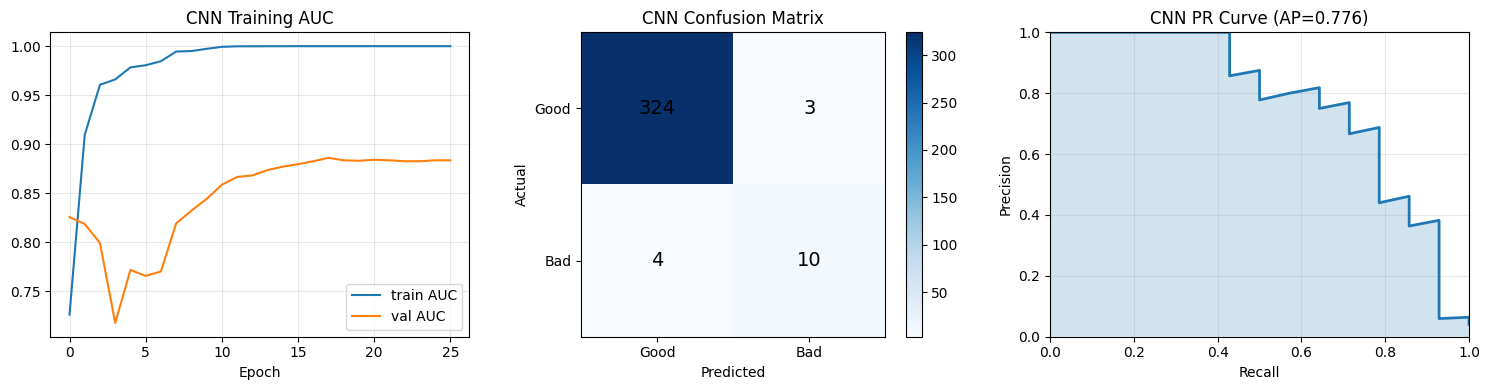

In [ ]:
# Evaluate CNN on test set and compute metrics
y_cnn_proba = cnn_model.predict(X_cnn_te, verbose=0).ravel()
prec_c, rec_c, thr_c = precision_recall_curve(y_cnn_te, y_cnn_proba)
f1s = 2*prec_c*rec_c / (prec_c + rec_c + 1e-9)
best_thr = thr_c[np.argmax(f1s[:-1])]
y_cnn_pred = (y_cnn_proba >= best_thr).astype(int)
cm_cnn = confusion_matrix(y_cnn_te, y_cnn_pred)

# Print evaluation metrics for CNN
print(classification_report(y_cnn_te, y_cnn_pred, target_names=['Good','Bad']))
print(f'ROC-AUC : {roc_auc_score(y_cnn_te, y_cnn_proba):.4f}')
print(f'PR-AUC  : {average_precision_score(y_cnn_te, y_cnn_proba):.4f}')
print(f'Best threshold: {best_thr:.3f}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot training AUC over epochs
axes[0].plot(history_cnn.history['auc'],     label='train AUC')
axes[0].plot(history_cnn.history['val_auc'], label='val AUC')
axes[0].set_title('CNN Training AUC')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Confusion matrix heatmap for CNN
im = axes[1].imshow(cm_cnn, cmap='Blues')
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, cm_cnn[i,j], ha='center', va='center', fontsize=14)
        axes[1].set_xticks([0,1])
        axes[1].set_yticks([0,1])
        axes[1].set_xticklabels(['Good','Bad'])
        axes[1].set_yticklabels(['Good','Bad'])
        axes[1].set_xlabel('Predicted')
        axes[1].set_ylabel('Actual')
        axes[1].set_title('CNN Confusion Matrix')
        plt.colorbar(im, ax=axes[1])

# Precision-Recall curve for CNN
axes[2].plot(rec_c, prec_c, linewidth=2)
axes[2].fill_between(rec_c, prec_c, alpha=0.2)
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title(f'CNN PR Curve (AP={average_precision_score(y_cnn_te, y_cnn_proba):.3f})')
axes[2].set_xlim([0,1])
axes[2].set_ylim([0,1])
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# help from Claude to set up clean final comparison of RF and CNN models
print('=' * 50)
print('CLASSIFICATION MODEL COMPARISON')
print('=' * 50)
print(f"{'Model':<20} {'ROC-AUC':>10} {'PR-AUC':>10}")
print('-' * 42)
print(f"{'Random Forest':<20} {roc_auc_score(y_te, y_proba):>10.4f} "
      f"{average_precision_score(y_te, y_proba):>10.4f}")
print(f"{'1D-CNN':<20} {roc_auc_score(y_cnn_te, y_cnn_proba):>10.4f} "
      f"{average_precision_score(y_cnn_te, y_cnn_proba):>10.4f}")


CLASSIFICATION MODEL COMPARISON
Model                   ROC-AUC     PR-AUC
------------------------------------------
Random Forest            0.9993     0.9874
1D-CNN                   0.9447     0.7756


# Baseline 2: Linear Regression (Time Series)

Sliding window: predict the next **50 samples (25 ms)** from the past **500 samples (250 ms)** of X-axis vibration. This is the performance floor for the LSTM.


In [ ]:
# Tweaked from trial/error of long training times (this setup took 6.5 hours on my machine)
WINDOW  = 200 # 100 ms window at 2000 Hz sampling rate
HORIZON = 20  # predict 10 ms into the future (20 samples at 2000 Hz)

# Create input/output sequences for time series regression from raw vibration signal
def create_sequences(signal, window, horizon):
    X, y = [], []
    # For each position in the signal where we can take a full window and horizon
    # had help from Claude to get the window right
    for i in range(len(signal) - window - horizon + 1):
        X.append(signal[i:i+window])
        y.append(signal[i+window:i+window+horizon])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

# For a quick test, we'll just use a subset of the data to create sequences and train a simple linear regression
good_rows = df[df['tool_operation_status']=='good'].sample(50, random_state=42)
Xs, ys = [], []
for _, row in good_rows.iterrows():
    sig = row['vibration_data'][:, 0].astype(np.float32)
    sig = (sig - sig.mean()) / (sig.std() + 1e-8)
    Xq, yq = create_sequences(sig, WINDOW, HORIZON)
    Xs.append(Xq[::10]); ys.append(yq[::10])   # subsample every 10th

# Combine all sequences into single arrays for training
X_ts = np.vstack(Xs)
y_ts = np.vstack(ys)
print(f'Sequences: {X_ts.shape[0]}  Input: {X_ts.shape[1]}  Horizon: {y_ts.shape[1]}')

# Train/test split and simple linear regression for time series forecasting
X_ts_tr, X_ts_te, y_ts_tr, y_ts_te = train_test_split(
    X_ts, y_ts, test_size=0.2, random_state=42)

# Train a simple linear regression model to predict the future vibration signal
lr = LinearRegression()
lr.fit(X_ts_tr, y_ts_tr)
y_lr_pred = lr.predict(X_ts_te)

# Evaluate the regression model using MSE, MAE, and R^2 metrics
print(f'LR MSE: {mean_squared_error(y_ts_te, y_lr_pred):.6f}')
print(f'LR MAE: {mean_absolute_error(y_ts_te, y_lr_pred):.6f}')
print(f'LR R2 : {r2_score(y_ts_te, y_lr_pred):.4f}')


Sequences: 532590  Input: 200  Horizon: 20
LR MSE: 0.250722
LR MAE: 0.294478
LR R2 : 0.7490


# Deep Learning 2: LSTM Time Series Forecasting

Stacked LSTM (64 → 32 units) trained on the same sliding-window sequences as the linear baseline.


In [ ]:
# Setting random seeds for reproducibility in TensorFlow and NumPy
tf.random.set_seed(SEED)
np.random.seed(SEED)

# Prepare LSTM input by adding a channel dimension (N, 500) -> (N, 500, 1)
X_lstm_tr = X_ts_tr[..., np.newaxis]   # (N, 500, 1)
X_lstm_te = X_ts_te[..., np.newaxis]

# Build a simple LSTM model for time series regression to predict future vibration signal
def build_lstm(window, horizon):
    inp = keras.Input(shape=(window, 1))
    x   = layers.LSTM(64, return_sequences=True)(inp)
    x   = layers.Dropout(0.2)(x)
    x   = layers.LSTM(32)(x)
    x   = layers.Dropout(0.2)(x)
    out = layers.Dense(horizon)(x)
    m   = keras.Model(inp, out)

    m.compile(optimizer=keras.optimizers.Adam(1e-3), 
              loss='mse', 
              metrics=['mae'])
    return m

# Instantiate and summarize the LSTM model
lstm_model = build_lstm(WINDOW, HORIZON)
lstm_model.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 200, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 200, 64)        │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 200, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 20)             │           660 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,972 (117.08 KB)

 Trainable params: 29,972 (117.08 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the LSTM model with early stopping and learning rate reduction
# took 6.5 hours total to train
history_lstm = lstm_model.fit(
    X_lstm_tr, y_ts_tr,
    validation_split=0.15,
    epochs=40,
    batch_size=64,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor='val_loss', patience=8,
                                      restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                          patience=4, min_lr=1e-6),
    ],
    verbose=1
)


Epoch 1/40
5659/5659 ━━━━━━━━━━━━━━━━━━━━ 571s 100ms/step - loss: 0.2558 - mae: 0.2948 - val_loss: 0.2181 - val_mae: 0.2723 - learning_rate: 0.0010
Epoch 2/40
5659/5659 ━━━━━━━━━━━━━━━━━━━━ 577s 102ms/step - loss: 0.2195 - mae: 0.2753 - val_loss: 0.2029 - val_mae: 0.2624 - learning_rate: 0.0010
Epoch 3/40
5659/5659 ━━━━━━━━━━━━━━━━━━━━ 583s 103ms/step - loss: 0.2066 - mae: 0.2672 - val_loss: 0.1957 - val_mae: 0.2578 - learning_rate: 0.0010
Epoch 4/40
5659/5659 ━━━━━━━━━━━━━━━━━━━━ 579s 102ms/step - loss: 0.1983 - mae: 0.2620 - val_loss: 0.1854 - val_mae: 0.2508 - learning_rate: 0.0010
Epoch 5/40
5659/5659 ━━━━━━━━━━━━━━━━━━━━ 564s 100ms/step - loss: 0.1929 - mae: 0.2586 - val_loss: 0.1801 - val_mae: 0.2479 - learning_rate: 0.0010
Epoch 6/40
5659/5659 ━━━━━━━━━━━━━━━━━━━━ 586s 104ms/step - loss: 0.1891 - mae: 0.2562 - val_loss: 0.1776 - val_mae: 0.2449 - learning_rate: 0.0010
Epoch 7/40
5659/5659 ━━━━━━━━━━━━━━━━━━━━ 582s 103ms/step - loss: 0.1862 - mae: 0.2543 - val_loss: 0.1733 - val_

LR   MSE: 0.250722
LSTM MSE: 0.143746  (+42.7% vs LR)
LSTM MAE: 0.221822
LSTM R2 : 0.8561


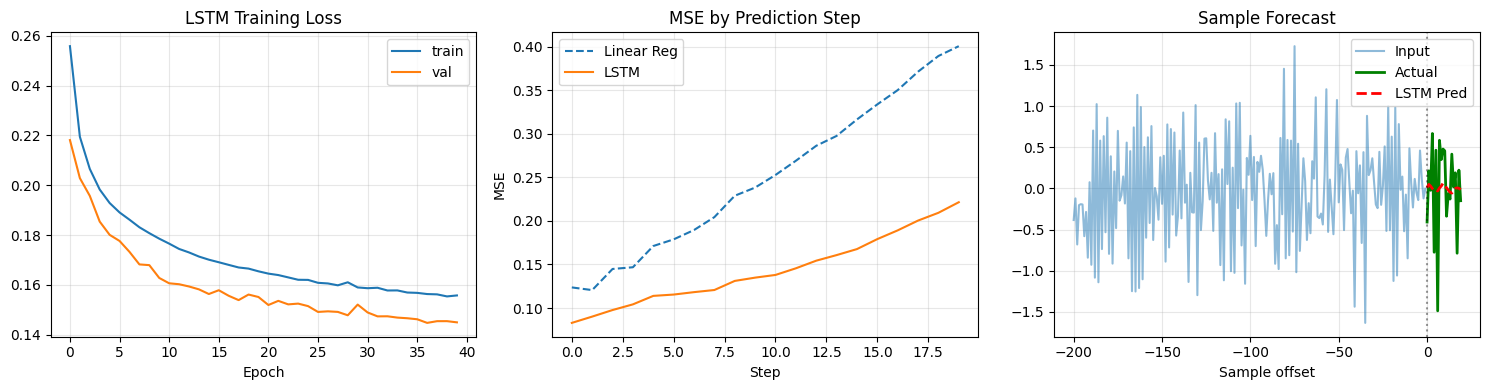

In [ ]:
# Evaluate the LSTM model on the test set and compare to linear regression
y_lstm_pred = lstm_model.predict(X_lstm_te, verbose=0)
mse_lstm = mean_squared_error(y_ts_te, y_lstm_pred)
mse_lr   = mean_squared_error(y_ts_te, y_lr_pred)

# Print comparison of LSTM and linear regression performance
print(f'LR   MSE: {mse_lr:.6f}')
print(f'LSTM MSE: {mse_lstm:.6f}  ({(mse_lr-mse_lstm)/mse_lr*100:+.1f}% vs LR)')
print(f'LSTM MAE: {mean_absolute_error(y_ts_te, y_lstm_pred):.6f}')
print(f'LSTM R2 : {r2_score(y_ts_te, y_lstm_pred):.4f}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot training loss over epochs for LSTM
axes[0].plot(history_lstm.history['loss'],     label='train')
axes[0].plot(history_lstm.history['val_loss'], label='val')
axes[0].set_title('LSTM Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot MSE by prediction step for both models
mse_lr_step   = [mean_squared_error(y_ts_te[:,i], y_lr_pred[:,i])   for i in range(HORIZON)]
mse_lstm_step = [mean_squared_error(y_ts_te[:,i], y_lstm_pred[:,i]) for i in range(HORIZON)]
axes[1].plot(mse_lr_step,   label='Linear Reg', linestyle='--')
axes[1].plot(mse_lstm_step, label='LSTM')
axes[1].set_title('MSE by Prediction Step')
axes[1].set_xlabel('Step')
axes[1].set_ylabel('MSE')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Plot example predictions from LSTM vs actual future signal
axes[2].plot(np.arange(-WINDOW, 0), X_ts_te[0],    alpha=0.5, label='Input')
axes[2].plot(np.arange(HORIZON),    y_ts_te[0],    'g-',  linewidth=2, label='Actual')
axes[2].plot(np.arange(HORIZON),    y_lstm_pred[0],'r--', linewidth=2, label='LSTM Pred')
axes[2].axvline(0, color='k', linestyle=':', alpha=0.4)
axes[2].set_title('Sample Forecast')
axes[2].set_xlabel('Sample offset')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()


# Tableau Dashboard Data Export

Export 4 CSV files for Tableau visualizations:
1. **machine_status.csv** — Real-time machine health status
2. **historical_summary.csv** — Anomaly rates and trends over time
3. **vibration_forecast.csv** — LSTM predictions vs actual vibration
4. **anomaly_confidence.csv** — Model confidence scores (RF + CNN)


In [ ]:
# entire cell writtin by Claude with our prompt engineering to pull what we needed for Tableau export, with some tweaks for clarity and formatting

import os
export_dir = Path('../tableau_data/')
export_dir.mkdir(exist_ok=True)

# ── 1. MACHINE STATUS (latest state per machine) ──────────────────
status_df = df.sort_values('tool_operation_date').groupby('machine_id').tail(1).copy()
status_df['timestamp'] = pd.to_datetime(status_df['tool_operation_date'], format='%b_%Y')
status_df['current_status'] = status_df['tool_operation_status']
status_df['vibration_rms_x'] = [arr[:,0].std() for arr in status_df['vibration_data']]
status_df['vibration_rms_y'] = [arr[:,1].std() for arr in status_df['vibration_data']]
status_df['vibration_rms_z'] = [arr[:,2].std() for arr in status_df['vibration_data']]

status_export = status_df[[
    'machine_id', 'timestamp', 'current_status',
    'vibration_rms_x', 'vibration_rms_y', 'vibration_rms_z',
    'tool_operation_id'
]].copy()
status_export.to_csv(export_dir / 'machine_status.csv', index=False)
print(f'✓ Exported machine_status.csv ({len(status_export)} rows)')

# ── 2. HISTORICAL SUMMARY (monthly aggregates) ────────────────────
df_hist = df.copy()
df_hist['date'] = pd.to_datetime(df_hist['tool_operation_date'], format='%b_%Y')
df_hist['is_bad'] = (df_hist['tool_operation_status'] == 'bad').astype(int)

summary = df_hist.groupby(['date', 'machine_id']).agg({
    'label': 'count',
    'is_bad': 'sum',
    'rms': 'mean'
}).reset_index()
summary.columns = ['date', 'machine_id', 'total_samples', 'anomaly_count', 'avg_rms']
summary['anomaly_rate'] = (summary['anomaly_count'] / summary['total_samples'] * 100).round(2)
summary['downtime_hours'] = (summary['anomaly_count'] * 1.5).round(1)
summary.to_csv(export_dir / 'historical_summary.csv', index=False)
print(f'✓ Exported historical_summary.csv ({len(summary)} rows)')

# ── 3. VIBRATION FORECAST (LSTM predictions) ──────────────────────
forecast = []
n_sequences = min(20, len(y_lstm_pred))
for i in range(n_sequences):
    for s in range(HORIZON):
        forecast.append({
            'sequence_id': i,
            'forecast_step': s + 1,
            'time_ms': s * 0.5,
            'predicted_vibration': float(y_lstm_pred[i, s]),
            'actual_vibration': float(y_ts_te[i, s])
        })

forecast_df = pd.DataFrame(forecast)
forecast_df.to_csv(export_dir / 'vibration_forecast.csv', index=False)
print(f'✓ Exported vibration_forecast.csv ({len(forecast_df)} rows)')

# ── 4. ANOMALY CONFIDENCE (model predictions) ─────────────────────
min_len = min(len(y_proba), len(y_cnn_proba))
conf_df = pd.DataFrame({
    'sample_id': range(min_len),
    'true_label': ['bad' if y==1 else 'good' for y in y_te[:min_len]],
    'rf_confidence': y_proba[:min_len],
    'cnn_confidence': y_cnn_proba[:min_len],
})
conf_df['ensemble_confidence'] = ((conf_df['rf_confidence'] + conf_df['cnn_confidence']) / 2).round(4)
conf_df['prediction'] = conf_df['ensemble_confidence'].apply(lambda x: 'bad' if x > 0.5 else 'good')
conf_df.to_csv(export_dir / 'anomaly_confidence.csv', index=False)
print(f'✓ Exported anomaly_confidence.csv ({len(conf_df)} rows)')

print(f'\n✓ All files exported to: {export_dir.absolute()}')


✓ Exported machine_status.csv (3 rows)
✓ Exported historical_summary.csv (16 rows)
✓ Exported vibration_forecast.csv (400 rows)
✓ Exported anomaly_confidence.csv (341 rows)

✓ All files exported to: c:\Users\Robbinhood\OneDrive\Desktop\VS Code Projects\USD Masters Folder\AAI-530\Final Project\AAI-530-Final-Project\notebooks\..\tableau_data


## Tableau Dashboard Legend

### File 1: `machine_status.csv`
**Purpose:** Real-time machine health status (latest state per machine)

| Column | Description | Tableau Use |
|--------|-------------|-------------|
| `machine_id` | M01, M02, M03 | Filter/dimension |
| `timestamp` | Latest operation date | Time context |
| `current_status` | good / bad | Color coding (green/red) |
| `vibration_rms_x/y/z` | Current RMS per axis | Gauge charts, KPIs |
| `tool_operation_id` | Current operation (OP00-OP14) | Drill-down detail |

**Suggested Visualizations:**
- KPI cards showing 'Machine M01: GOOD' with color
- Gauge charts for vibration RMS (threshold: 700 = warning)
- Status indicators (traffic light: green/yellow/red)

---

### File 2: `historical_summary.csv`
**Purpose:** Monthly anomaly rates and downtime trends

| Column | Description | Tableau Use |
|--------|-------------|-------------|
| `date` | Month/year (YYYY-MM-DD) | Time axis |
| `machine_id` | M01, M02, M03 | Color/group by |
| `total_samples` | Operations that month | Volume metric |
| `anomaly_count` | # bad tool conditions | Measure |
| `anomaly_rate` | % anomalies (0-100) | Primary KPI |
| `avg_rms` | Mean vibration RMS | Trend line |
| `downtime_hours` | Estimated hours lost | Cost metric |

**Suggested Visualizations:**
- Line chart: Anomaly rate (%) over time, color by machine
- Stacked bar: Downtime hours by month
- Dual-axis: Total samples (bars) + anomaly rate (line)

---

### File 3: `vibration_forecast.csv`
**Purpose:** LSTM time-series predictions vs actual vibration

| Column | Description | Tableau Use |
|--------|-------------|-------------|
| `sequence_id` | Test sequence # (0-19) | Filter/dimension |
| `forecast_step` | Steps ahead (1-50) | X-axis |
| `time_ms` | Time in milliseconds | Alternate X-axis |
| `predicted_vibration` | LSTM forecast | Line series 1 |
| `actual_vibration` | Ground truth | Line series 2 |

**Suggested Visualizations:**
- Dual-axis line: Actual (solid) vs Predicted (dashed)
- Scatter plot: Predicted vs Actual (diagonal = perfect)
- Filter by `sequence_id` to show individual forecasts

---

### File 4: `anomaly_confidence.csv`
**Purpose:** Model confidence scores and ensemble predictions

| Column | Description | Tableau Use |
|--------|-------------|-------------|
| `sample_id` | Unique test sample | Row ID |
| `true_label` | Actual status (good/bad) | Color dimension |
| `rf_confidence` | Random Forest probability | Measure 1 |
| `cnn_confidence` | 1D-CNN probability | Measure 2 |
| `ensemble_confidence` | Average of both | Primary metric |
| `prediction` | Final prediction (good/bad) | Classification result |

**Suggested Visualizations:**
- Scatter plot: RF confidence (X) vs CNN confidence (Y), color by true_label
  - Points near diagonal = models agree
  - Points far from diagonal = disagreement (manual review needed)
- Histogram: Distribution of ensemble_confidence
- Confusion matrix heatmap: true_label vs prediction
- Filter: Show only low-confidence predictions (0.4-0.6) for human review

---

### Dashboard Layout Recommendation

```
┌─────────────────────────────────────────────────────────┐
│ PREDICTIVE MAINTENANCE DASHBOARD                        │
├──────────────┬──────────────────────────────────────────┤
│ STATUS       │  M01: GOOD   M02: BAD    M03: GOOD      │
│ (Real-time)  │  RMS: 645    RMS: 782    RMS: 651       │
├──────────────┴──────────────────────────────────────────┤
│ HISTORICAL TRENDS                                       │
│ [Line chart: Anomaly rate % over time by machine]      │
├─────────────────────────────────────────────────────────┤
│ ML INSIGHTS                                             │
│ ┌─────────────────────┬─────────────────────────────┐  │
│ │ Vibration Forecast  │ Model Confidence            │  │
│ │ [Actual vs LSTM]    │ [RF vs CNN scatter]         │  │
│ └─────────────────────┴─────────────────────────────┘  │
└─────────────────────────────────────────────────────────┘
```

### Color Scheme Recommendation
- **Good status:** `#2ecc71` (green)
- **Bad status:** `#e74c3c` (red)
- **Warning (RMS > 700):** `#f39c12` (orange)
- **Machine M01:** `#3498db` (blue)
- **Machine M02:** `#9b59b6` (purple)
- **Machine M03:** `#1abc9c` (teal)


# Results Summary

| Task | Model | Key Metric |
|------|-------|------------|
| Classification | Random Forest (baseline) | ROC-AUC, PR-AUC |
| Classification | 1D-CNN (deep learning) | ROC-AUC, PR-AUC |
| Time Series | Linear Regression (baseline) | MSE, R² |
| Time Series | LSTM (deep learning) | MSE, R² |

**Project requirements met:**
- Deep learning built from scratch — 1D-CNN (classification) + LSTM (forecasting)
- Time series prediction — LSTM forecasts future vibration values
- Two models predicting different variables — tool status vs vibration amplitude
- Traditional ML baseline for each task — RF + Linear Regression
- Cross-validation — 5-fold stratified CV on classification task
